# 1) Importing the needed packages

In [11]:
import pandas as pd
import numpy as np
from datetime import datetime

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 14, Finished, Available, Finished, False)

# 2) Reading raw data

In [12]:
df = spark.table("ODS.employee_text_data_combined")
df = df.toPandas()

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 15, Finished, Available, Finished, False)

# 3) General Exploration

In [13]:
df.head()

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 16, Finished, Available, Finished, False)

,emp_id,full_name,fname,lname,birth_date,dept_name,country,monthly_salary,sex,job_title,employee_status,education,load_timestamp,source_location,file_type,was_error
0,100126,Laila Patel,LAILA,Patel,2003/10/30,Marketing,SA,19487.25,1,Business Analyst,External,bachelor,2026-07-17 23:41:00,Files/employee_dirty_files_pre_ODS/employee_di...,txt,NO SCHEMA ERROR
1,100127,Olivia Moore,Olivia,Moore,1999-02-12,human resources,EG,29728.5,Male,Business Analyst,Terminated,phd,2026-07-17 23:41:00,Files/employee_dirty_files_pre_ODS/employee_di...,txt,NO SCHEMA ERROR
2,100128,Aisha Miller,Aisha,Miller,1973/10/13,Sales,Pakistan,"24,364",1,Business Analyst,on leave,DIP,2026-07-17 23:41:00,Files/employee_dirty_files_pre_ODS/employee_di...,txt,NO SCHEMA ERROR
3,100129,"Williams, Faisal",Faisal,Williams,02-11-1995,env.,JOR,N/A,FEMALE,Production Operator,PROB,MSc,2026-07-17 23:41:00,Files/employee_dirty_files_pre_ODS/employee_di...,txt,NO SCHEMA ERROR
4,100130,Olivia Ali,Olivia,Ali,1990/04/09,Safety,usa,"20,730",2,Safety Officer,A,diploma,2026-07-17 23:41:00,Files/employee_dirty_files_pre_ODS/employee_di...,txt,NO SCHEMA ERROR


In [14]:
df.tail()

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 17, Finished, Available, Finished, False)

,emp_id,full_name,fname,lname,birth_date,dept_name,country,monthly_salary,sex,job_title,employee_status,education,load_timestamp,source_location,file_type,was_error
995,100889,"Johnson, Noora",Noora,Johnson,1974-02-05,HR,SA,N/A,female,Business Analyst,Probation,bachelor,2026-07-17 23:41:00,Files/employee_dirty_files_pre_ODS/employee_di...,txt,EXTRA_FIXED
996,100125,"Al-Kuwari, Aya",Aya,Al-Kuwari,09-28-1967,Production,IND,"$35,663.75",F,HR Specialist,CONT,MBA,2026-07-17 23:41:00,Files/employee_dirty_files_pre_ODS/employee_di...,txt,EXTRA_FIXED
997,100333,Ava Mahmoud,Ava,Mahmoud,07/09/1990,Finance,egypt,38851.25,2,HR Specialist,probation,PhD,2026-07-17 23:41:00,Files/employee_dirty_files_pre_ODS/employee_di...,txt,EXTRA_FIXED
998,100250,Heba Mostafa,Heba,Mostafa,None,SALES,Jordan,44676,Male,Supply Chain Coordinator,on leave,None,2026-07-18 10:39:02,Tables/ODS/employee_text_data_errors,txt,MISSING_FIXED
999,100501,Layla Miller,Layla,Miller,14/08/1995,PROD,uk,12250.75,M,Accountant,None,None,2026-07-18 10:39:02,Tables/ODS/employee_text_data_errors,txt,MISSING_FIXED


In [15]:
df.info()

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 18, Finished, Available, Finished, False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   emp_id           1000 non-null   object
 1   full_name        1000 non-null   object
 2   fname            1000 non-null   object
 3   lname            1000 non-null   object
 4   birth_date       999 non-null    object
 5   dept_name        1000 non-null   object
 6   country          1000 non-null   object
 7   monthly_salary   1000 non-null   object
 8   sex              1000 non-null   object
 9   job_title        1000 non-null   object
 10  employee_status  999 non-null    object
 11  education        998 non-null    object
 12  load_timestamp   1000 non-null   object
 13  source_location  1000 non-null   object
 14  file_type        1000 non-null   object
 15  was_error        1000 non-null   object
dtypes: object(16)
memory usage: 125.1+ KB


### Note 1: Nulls are hidden, because of some changes done to the meta data while checking for the data schema

In [16]:
df.describe()

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 19, Finished, Available, Finished, False)

,emp_id,full_name,fname,lname,birth_date,dept_name,country,monthly_salary,sex,job_title,employee_status,education,load_timestamp,source_location,file_type,was_error
count,1000,1000,1000,1000,999,1000,1000,1000,1000,1000,999,998,1000,1000,1000,1000
unique,996,773,58,41,942,50,51,967,15,12,26,27,2,2,1,3
top,100743,Omar Jones,James,Jones,,Sales Dept,Qatar,,female,Project Manager,Contractor,Doctorate,2026-07-17 23:41:00,Files/employee_dirty_files_pre_ODS/employee_di...,txt,NO SCHEMA ERROR
freq,2,5,42,43,32,32,32,21,96,105,54,47,998,998,1000,993


# 4) Structural & Meta-Data Exploration

## 4.1) Structural & Meta-Data Exploration: Dimensionality/Shape

In [17]:
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 20, Finished, Available, Finished, False)

Shape: 1,000 rows × 16 columns


## 4.2) Structural & Meta-Data Exploration: Data Types and Data Classification

In [18]:
# Inspect raw data types
print("="*80)
print("RAW DATA TYPES")
print("="*80)
print(df.dtypes)
print("\n" + "="*80)
print("DATA ENGINEERING - COLUMN CLASSIFICATION")
print("="*80)

for col in df.columns:
    dtype = df[col].dtype
    n = len(df)
    unique = df[col].nunique()
    null_pct = df[col].isnull().sum() / n * 100
    sample_values = df[col].dropna().unique()[:3].tolist() if n > 0 else []
    
    # ---- DATA ENGINEERING CLASSIFICATION LOGIC ----
    
    # 1. CONSTANT (no variance) - HIGHEST PRIORITY
    if unique == 1:
        classification = "CONSTANT (DROP - no information value)"
    
    # 2. IDENTIFIER (high cardinality, likely ID)
    elif col.lower() in ['id', 'userid', 'sessionid', 'studentid', 'employeeid', 'emp_id'] or col.lower().endswith('id'):
        classification = "IDENTIFIER (exclude from aggregations - use as key)"
    
    # 3. DATETIME (if already datetime type)
    elif 'datetime' in str(dtype):
        classification = "DATETIME (extract components: year, month, day, hour)"
    
    # 4. TEXT_DATE (string that looks like a date)
    elif str(dtype) in ['object', 'str', 'string'] and any(x in col.lower() for x in ['date', 'time', 'timestamp']):
        classification = "DATE_STRING (parse to datetime and extract components)"
    
    # 5. MIXED_TYPE (check for mixed types in object/str columns)
    elif str(dtype) in ['object', 'str', 'string']:
        type_sample = df[col].dropna().apply(type).nunique()
        if type_sample > 1:
            classification = f"MIXED_TYPE (clean - convert to single type, check for delimiter issues)"
        # 6. HIGH_CARDINALITY_TEXT (text with many unique)
        elif unique > n * 0.5 or unique > 1000:
            classification = "FREE_TEXT (exclude from analysis - use for text mining)"
        # 7. LOW_CARDINALITY_TEXT (categorical string)
        else:
            classification = "CATEGORICAL_STRING (encode as dictionary or one-hot)"
    
    # 8. BINARY_INDICATOR (int-coded binary)
    elif str(dtype) in ['int64', 'int32', 'int16'] and set(sample_values).issubset({0, 1}):
        classification = "BINARY_FLAG (use as boolean - 0/1)"
    
    # 9. BINARY (exactly 2 unique values)
    elif unique == 2:
        classification = "BINARY_INDICATOR (encode as 0/1 for efficient storage)"
    
    # 10. ORDINAL (numeric with few values, ordered)
    elif str(dtype) in ['int64', 'int32', 'int16'] and unique <= 10:
        classification = "ORDINAL_INDEX (preserve order as integer)"
    
    # 11. COUNT_DATA (integer counts)
    elif str(dtype) in ['int64', 'int32', 'int16'] and df[col].min() >= 0:
        classification = "COUNT_DATA (keep as integer - check for skewness)"
    
    # 12. PERCENTAGE (bounded 0-1 or 0-100)
    elif str(dtype) in ['float64', 'float32'] and any(x in col.lower() for x in ['pct', 'percent', 'rate']):
        min_val = df[col].min()
        max_val = df[col].max()
        if min_val >= 0 and max_val <= 1:
            classification = "PERCENTAGE_DECIMAL (scale to 0-100 if needed)"
        elif min_val >= 0 and max_val <= 100:
            classification = "PERCENTAGE (check for normalization needs)"
        else:
            classification = "PERCENTAGE_OUT_OF_RANGE (investigate - values outside expected range)"
    
    # 13. LOW_CARDINALITY_CONTINUOUS (float with few values)
    elif str(dtype) in ['float64', 'float32'] and unique < 20:
        classification = "LOW_DISTINCT_FLOAT (check if should be integer/categorical)"
    
    # 14. CONTINUOUS (true numeric)
    elif str(dtype) in ['int64', 'float64', 'int32', 'float32', 'int16', 'float16']:
        classification = "CONTINUOUS_NUMERIC (scale before use, check outliers)"
    
    # 15. METADATA/Lineage columns
    elif col in ['load_timestamp', 'source_location', 'file_type', 'was_error']:
        classification = "METADATA (audit/lineage tracking)"
    
    # 16. FALLBACK
    else:
        classification = f"UNCLASSIFIED (investigate - dtype: {dtype})"
    
    # ---- DISPLAY RESULTS ----
    print(f"\n{col}:")
    print(f"  ▶ Engineering Classification: {classification}")
    print(f"  ▶ Current Type: {dtype}")
    print(f"  ▶ Distinct Values: {unique:,}")
    print(f"  ▶ Null Percentage: {null_pct:.1f}%")
    if sample_values:
        print(f"  ▶ Sample Values: {sample_values}")
    print("-" * 50)

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 21, Finished, Available, Finished, False)

RAW DATA TYPES
emp_id             object
full_name          object
fname              object
lname              object
birth_date         object
dept_name          object
country            object
monthly_salary     object
sex                object
job_title          object
employee_status    object
education          object
load_timestamp     object
source_location    object
file_type          object
was_error          object
dtype: object

DATA ENGINEERING - COLUMN CLASSIFICATION

emp_id:
  ▶ Engineering Classification: IDENTIFIER (exclude from aggregations - use as key)
  ▶ Current Type: object
  ▶ Distinct Values: 996
  ▶ Null Percentage: 0.0%
  ▶ Sample Values: ['100126', '100127', '100128']
--------------------------------------------------

full_name:
  ▶ Engineering Classification: FREE_TEXT (exclude from analysis - use for text mining)
  ▶ Current Type: object
  ▶ Distinct Values: 773
  ▶ Null Percentage: 0.0%
  ▶ Sample Values: ['Laila Patel', 'Olivia Moore', 'Aisha Miller']


## 4.3) Structural & Meta-Data Exploration: Column Header Audit

In [19]:
# Check for trailing/leading whitespace in column headers
print("=== COLUMNS WITH LEADING/TRAILING WHITESPACE ===")
found_whitespace = False
for col in df.columns:
    if col != col.strip():
        print(f"'{col}'")
        found_whitespace = True
if not found_whitespace:
    print("None")
print("\n")

# Check for special characters in column names
print("=== COLUMNS WITH SPECIAL CHARACTERS ===")
allowed = 'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_'
found_special = False
for col in df.columns:
    has_special = False
    for char in col:
        if char not in allowed:
            has_special = True
            break
    if has_special:
        print(f"'{col}'")
        found_special = True
if not found_special:
    print("None")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 22, Finished, Available, Finished, False)

=== COLUMNS WITH LEADING/TRAILING WHITESPACE ===
None


=== COLUMNS WITH SPECIAL CHARACTERS ===
None


## Issue #1: Unstandardized Column Names
Column names use inconsistent formats with spaces, abbreviations, and lowercase.

**Examples:**
- `emp_id` instead of `EmployeeId`
- `fname` instead of `FirstName`
- `dept_name` instead of `DepartmentName`
- `sex` instead of `Gender`

### Solution: Rename to PascalCase with Full Descriptive Names
Convert all column names to title format without spaces and expand abbreviations.

In [20]:
# Rename columns to Title Format without spaces and no abbreviations
df = df.rename(columns={
    'emp_id': 'EmployeeId',
    'full_name': 'FullName',
    'fname': 'FirstName',
    'lname': 'LastName',
    'birth_date': 'BirthDate',
    'dept_name': 'DepartmentName',
    'country': 'Country',
    'monthly_salary': 'MonthlySalary',
    'sex': 'Gender',
    'job_title': 'JobTitle',
    'employee_status': 'EmployeeStatus',
    'education': 'EducationLevel',
    'load_timestamp': 'LoadTimestamp',
    'source_location': 'SourceLocation',
    'file_type': 'FileType',
    'was_error': 'WasError'
})

# Verify
print(df.dtypes)

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 23, Finished, Available, Finished, False)

EmployeeId        object
FullName          object
FirstName         object
LastName          object
BirthDate         object
DepartmentName    object
Country           object
MonthlySalary     object
Gender            object
JobTitle          object
EmployeeStatus    object
EducationLevel    object
LoadTimestamp     object
SourceLocation    object
FileType          object
WasError          object
dtype: object


# 5) Data Quality Checks/Assessment

### 5.1) FORMAT/VALUE STANDARDIZATION
*Standardize inconsistent formats and values.*

- **Categorical Standardization**: Normalize variations (Male, male, M, 1 → MALE)
- **Numeric Cleanup**: Remove currency symbols, commas, units from numeric fields
- **Date Standardization**: Convert all dates to consistent format
- **Text Normalization**: Trim whitespace, handle capitalization
- **Boolean Encoding**: Convert Yes/No, True/False, 1/0 to consistent format

---

### 5.2) VALIDITY CHECKS
*Verify data conforms to expected formats, types, and domains.*

- **Data Type Violations**: Check if columns contain correct data types (e.g., numeric in numeric columns)
- **Invalid Categories**: Values not found in allowed list (e.g., sex only 'M', 'F', 'Other')
- **Pattern Mismatches**: Format violations like date formats, email patterns, phone numbers
- **Range Violations**: Values outside allowed min/max bounds
- **Format Consistency**: Standardized formats for dates, phone numbers, codes, etc.

---

### 5.3) COMPLETENESS CHECKS
*Measure and understand missing data to ensure no critical gaps.*

- **Missing Values per Column**: Null percentage per column
- **Missing Values per Row**: Identify rows with excessive missing values
- **Missing Data Patterns**: Check if missing values are random (MCAR/MAR) or systematic (MNAR)
- **Missing Value Correlation**: Determine if missingness in one column is related to another column

---

### 5.4) UNIQUENESS CHECKS
*Ensure no duplicate data exists and each record is uniquely identifiable.*

- **Duplicate Rows**: Check if entire rows are duplicated
- **Duplicate IDs**: Verify primary/unique key columns have no duplicates
- **Unique Value Counts**: Check distinct value distribution in categorical columns (too few/too many)

---

### 5.5) CONSISTENCY CHECKS
*Validate logical relationships and contradictions across columns.*

- **Cross-Column Validation**: Verify logical relationships (e.g., fname + lname = full_name)
- **Logical Contradictions**: Values that conflict logically (e.g., age < 18 and job_title = 'CEO')
- **Dependency Violations**: Business rule violations (e.g., employee_status = 'Terminated' but end_date is null)
- **Value Range Logic**: Ranges that don't make sense together (e.g., birth_date > hire_date)
- **Category Mapping**: Inconsistent codes/descriptions across related columns
- **Foreign Key Consistency**: Check that referenced values exist in lookup tables

---

### 5.6) ACCURACY CHECKS
*Identify statistical anomalies and business rule violations.*

- **Outlier Detection**: Values that deviate significantly from the mean/median
- **Statistical Anomalies**: Distribution imbalances, sudden spikes/drops
- **Business Rule Violations**: Values that break defined business rules (e.g., salary > 1M)
- **Impossible Values**: Values that cannot exist (e.g., negative age, future birth_date)

---

### 5.7) DOMAIN VALIDATION
*Check business-specific domain constraints.*

- **Allowed Value Lists**: Verify values against predefined allowed lists
- **Geographic Validation**: Check country codes, city names against valid lists
- **Department Validation**: Check department names against valid organizational list
- **Salary Band Validation**: Verify salaries fall within expected ranges
- **Date Range Validation**: Check dates against business calendar (e.g., hire_date after 1980)

---

### 5.8) REFERENTIAL INTEGRITY CHECKS
*Ensure relationships between tables are valid and no broken links exist.*

- **Orphan Records**: Records with foreign keys that don't exist in parent tables
- **Invalid Foreign Keys**: Foreign key values that don't reference valid primary keys
- **Missing Parent Records**: Child records without corresponding parent

---

### 5.9) TIMELINESS CHECKS
*Monitor data freshness and temporal patterns.*

- **Data Freshness**: Age of data and last update timestamp
- **Load Timestamp Analysis**: Check consistency of load timestamps
- **Source-to-Target Latency**: Delay between source generation and loading
- **Temporal Consistency**: Check if timestamps are logical (not future dates, not too old)
- **Temporal Gaps**: Missing time periods in time-series data

---


## 5.1.1) FORMAT/VALUE STANDARDIZATION: Categorical Standardization: Normalize variations (Male, male, M, 1 → MALE)

In [21]:
categorical_cols = ['Gender', 'DepartmentName', 'Country', 'EmployeeStatus', 'EducationLevel', 'JobTitle']

for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(f"Unique values: {df[col].unique()}")
    print(f"Count: {df[col].nunique()}")
    print(f"Value counts:\n{df[col].value_counts(dropna=False)}")
    print("-" * 50)

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 24, Finished, Available, Finished, False)


=== Gender ===
Unique values: ['1' 'Male' 'FEMALE' '2' 'M' ' f ' 'MALE' 'F' 'male' ' m ' 'female'
 'Female' 'Unknown' 'N/A' '']
Count: 15
Value counts:
Gender
female     96
Male       94
1          89
 f         86
FEMALE     84
2          84
F          80
M          79
 m         78
MALE       74
Female     70
male       57
N/A        11
           10
Unknown     8
Name: count, dtype: int64
--------------------------------------------------

=== DepartmentName ===
Unique values: ['Marketing' 'human resources' 'Sales' 'env.' 'Safety' 'finance'
 ' production ' 'OPS' 'Production' 'H.R.' 'ops' 'Logistics' 'MKT'
 'supply-chain' 'Manufacturing' ' Supply Chain ' 'Sales Dept' 'it'
 ' Marketing ' 'Information Technology' 'Finance' ' safety ' 'EHS'
 'Operations' 'SCM' 'sales' ' Accounting ' 'ENV' 'FIN' ' Commercial '
 ' Environmental ' 'Environmental' 'Fin.' 'HSE' ' IT ' 'Supply Chain'
 'Prod' ' Operations ' 'HR' 'IT' 'marketting' 'Environment' 'I.T.'
 'Operation' 'PROD' ' HR ' 'SALES' 'Human 

### Issue #2: Inconsistent Gender Values
Multiple variations of gender values refer to the same category.

**Examples:**
- Male variants: `1`, `M`, `Male`, `male`, `MALE`, ` m `
- Female variants: `2`, `F`, `Female`, `female`, `FEMALE`, ` f `
- Invalid values: `Unknown`, `N/A`, empty string

### Solution: Standardize to 'Male' / 'Female' / None
Map all variations to a single canonical value per category and convert invalid entries to `None`.

In [22]:
# Define mapping for Gender column
sex_mapping = {
    '1': 'Male',
    '2': 'Female',
    'M': 'Male',
    'F': 'Female',
    'MALE': 'Male',
    'FEMALE': 'Female',
    'male': 'Male',
    'female': 'Female',
    'Male': 'Male',
    'Female': 'Female',
    ' m ': 'Male',
    ' f ': 'Female',
    '': None,
    'Unknown': None,
    'N/A': None
}

# Apply mapping
df['Gender'] = df['Gender'].astype(str).str.strip().map(sex_mapping)

# Convert any remaining NaN to None
df['Gender'] = df['Gender'].where(df['Gender'].notna(), None)

# Verify
print("=== Gender after standardization ===")
print(f"Unique values: {df['Gender'].unique()}")
print(f"Count: {df['Gender'].nunique()}")
print(f"Value counts:\n{df['Gender'].value_counts(dropna=False)}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 25, Finished, Available, Finished, False)

=== Gender after standardization ===
Unique values: ['Male' 'Female' None]
Count: 2
Value counts:
Gender
Female    414
Male      393
None      193
Name: count, dtype: int64


### Issue #3: Inconsistent DepartmentName Values
Multiple variations of department names refer to the same department.

**Examples:**
- Marketing variants: `Marketing`, `MKT`, `mktg`, `marketting`, ` Marketing `
- Human Resources variants: `human resources`, `H.R.`, `HR`, ` HR `

### Solution: Map All Variants to Standardized Department Names
Create a mapping dictionary to normalize each variant to its canonical department name.

In [23]:
# Define mapping for DepartmentName column
dept_mapping = {
    'Marketing': 'Marketing',
    ' Marketing ': 'Marketing',
    'MKT': 'Marketing',
    'mktg': 'Marketing',
    'marketting': 'Marketing',
    
    'human resources': 'Human Resources',
    'Human Resources': 'Human Resources',
    'H.R.': 'Human Resources',
    'HR': 'Human Resources',
    ' HR ': 'Human Resources',
    
    'Sales': 'Sales',
    'Sales Dept': 'Sales',
    'sales': 'Sales',
    'SALES': 'Sales',
    ' Commercial ': 'Sales',
    
    'env.': 'Environment',
    'Environment': 'Environment',
    'Environmental': 'Environment',
    ' Environmental ': 'Environment',
    'ENV': 'Environment',
    
    'Safety': 'Safety',
    ' safety ': 'Safety',
    'Health & Safety': 'Safety',
    'HSE': 'Safety',
    'EHS': 'Safety',
    
    'finance': 'Finance',
    'Finance': 'Finance',
    'Fin.': 'Finance',
    'FIN': 'Finance',
    ' Accounting ': 'Finance',
    
    ' production ': 'Production',
    'Production': 'Production',
    'Prod': 'Production',
    'PROD': 'Production',
    
    'OPS': 'Operations',
    'ops': 'Operations',
    'Operations': 'Operations',
    ' Operations ': 'Operations',
    'Operation': 'Operations',
    
    'Logistics': 'Logistics',
    
    'supply-chain': 'Supply Chain',
    'Supply Chain': 'Supply Chain',
    ' Supply Chain ': 'Supply Chain',
    'SCM': 'Supply Chain',
    
    'Manufacturing': 'Manufacturing',
    
    'it': 'IT',
    'IT': 'IT',
    ' IT ': 'IT',
    'I.T.': 'IT',
    'Information Technology': 'IT'
}

# Apply mapping
df['DepartmentName'] = df['DepartmentName'].astype(str).str.strip().map(dept_mapping)

# Convert any remaining NaN to None
df['DepartmentName'] = df['DepartmentName'].where(df['DepartmentName'].notna(), None)

# Verify
print("=== DepartmentName after standardization ===")
print(f"Unique values: {df['DepartmentName'].unique()}")
print(f"Count: {df['DepartmentName'].nunique()}")
print(f"Value counts:\n{df['DepartmentName'].value_counts(dropna=False)}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 26, Finished, Available, Finished, False)

=== DepartmentName after standardization ===
Unique values: ['Marketing' 'Human Resources' 'Sales' 'Environment' 'Safety' 'Finance'
 None 'Operations' 'Production' 'Logistics' 'Supply Chain' 'Manufacturing'
 'IT']
Count: 12
Value counts:
DepartmentName
IT                 106
Sales               99
Environment         97
Operations          93
Human Resources     92
Finance             89
Safety              86
Marketing           85
None                75
Supply Chain        73
Production          64
Manufacturing       21
Logistics           20
Name: count, dtype: int64


### Issue #4: Inconsistent Country Values
Multiple variations of country names, codes, and formats refer to the same country.

**Examples:**
- Saudi Arabia variants: `SA`, `saudi arabia`, `KSA`, ` Saudi `, `Saudi Arabia`
- Egypt variants: `EG`, `egypt`, `Egypt`, `EGY`, ` Egypt `
- Pakistan variants: `Pakistan`, `PAK`, `pakistan`, ` Pakistan `

### Solution: Map All Country Codes and Variants to Full Standardized Country Names

In [24]:
# Define mapping for Country column
country_mapping = {
    'SA': 'Saudi Arabia',
    'saudi arabia': 'Saudi Arabia',
    'KSA': 'Saudi Arabia',
    ' Saudi ': 'Saudi Arabia',
    'Saudi Arabia': 'Saudi Arabia',
    
    'EG': 'Egypt',
    'egypt': 'Egypt',
    'Egypt': 'Egypt',
    'EGY': 'Egypt',
    ' Egypt ': 'Egypt',
    
    'Pakistan': 'Pakistan',
    'PAK': 'Pakistan',
    'pakistan': 'Pakistan',
    ' Pakistan ': 'Pakistan',
    
    'JOR': 'Jordan',
    'JO': 'Jordan',
    'jordan': 'Jordan',
    'Jordan': 'Jordan',
    ' Jordan ': 'Jordan',
    
    ' usa ': 'USA',
    'US': 'USA',
    'USA': 'USA',
    'United States': 'USA',
    'United States of America': 'USA',
    
    'GB': 'UK',
    'United Kingdom': 'UK',
    'Britain': 'UK',
    'UK': 'UK',
    ' uk ': 'UK',
    'uk': 'UK',
    
    'IND': 'India',
    'IN': 'India',
    'India': 'India',
    'india': 'India',
    ' India ': 'India',
    
    'Emirates': 'UAE',
    'AE': 'UAE',
    'UAE': 'UAE',
    ' UAE ': 'UAE',
    'United Arab Emirates': 'UAE',
    
    'QA': 'Qatar',
    'QAT': 'Qatar',
    'Qatar': 'Qatar',
    'qatar': 'Qatar',
    ' Qatar ': 'Qatar',
    
    'PH': 'Philippines',
    'PHL': 'Philippines',
    'philippines': 'Philippines',
    'Philippines': 'Philippines',
    ' Philippines ': 'Philippines',
    
    'PK': 'Pakistan'
}

# Apply mapping
df['Country'] = df['Country'].astype(str).str.strip().map(country_mapping)

# Convert any remaining NaN to None
df['Country'] = df['Country'].where(df['Country'].notna(), None)

# Verify
print("=== Country after standardization ===")
print(f"Unique values: {df['Country'].unique()}")
print(f"Count: {df['Country'].nunique()}")
print(f"Value counts:\n{df['Country'].value_counts(dropna=False)}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 27, Finished, Available, Finished, False)

=== Country after standardization ===
Unique values: ['Saudi Arabia' 'Egypt' 'Pakistan' 'Jordan' None 'UK' 'Philippines' 'UAE'
 'India' 'Qatar' 'USA']
Count: 10
Value counts:
Country
India           117
Jordan          110
Qatar           108
UAE             104
Pakistan        103
Philippines      91
UK               88
Egypt            85
USA              85
Saudi Arabia     73
None             36
Name: count, dtype: int64


### Issue #5: Inconsistent EmployeeStatus Values
Multiple variations of employee status values refer to the same status category.

**Examples:**
- Active variants: `A`, `active`, `Active`, `ACT`, ` Active `
- Terminated variants: `Terminated`, `terminated`, `TERM`, ` Terminated `

### Solution: Map All Variants to Standardized Employee Status Values

In [25]:
# Define mapping for EmployeeStatus column
status_mapping = {
    'A': 'Active',
    'active': 'Active',
    'Active': 'Active',
    'ACT': 'Active',
    ' Active ': 'Active',
    
    'Terminated': 'Terminated',
    'terminated': 'Terminated',
    'TERM': 'Terminated',
    ' Terminated ': 'Terminated',
    
    'on leave': 'On Leave',
    'Leave': 'On Leave',
    'On Leave': 'On Leave',
    ' On Leave ': 'On Leave',
    'ON_LEAVE': 'On Leave',
    
    'PROB': 'Probation',
    'Probation': 'Probation',
    'probation': 'Probation',
    ' Probation ': 'Probation',
    
    'contractor': 'Contractor',
    'Contractor': 'Contractor',
    'CONT': 'Contractor',
    ' Contractor ': 'Contractor',
    
    'New Hire': 'New Hire',
    'External': 'External',
    'Inactive': 'Inactive',
    
    '': None
}

# Apply mapping
df['EmployeeStatus'] = df['EmployeeStatus'].astype(str).str.strip().map(status_mapping)

# Convert any remaining NaN to None
df['EmployeeStatus'] = df['EmployeeStatus'].where(df['EmployeeStatus'].notna(), None)

# Verify
print("=== EmployeeStatus after standardization ===")
print(f"Unique values: {df['EmployeeStatus'].unique()}")
print(f"Count: {df['EmployeeStatus'].nunique()}")
print(f"Value counts:\n{df['EmployeeStatus'].value_counts(dropna=False)}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 28, Finished, Available, Finished, False)

=== EmployeeStatus after standardization ===
Unique values: ['External' 'Terminated' 'On Leave' 'Probation' 'Active' 'Contractor'
 'New Hire' 'Inactive' None]
Count: 8
Value counts:
EmployeeStatus
Active        207
On Leave      176
Contractor    174
Terminated    167
Probation     147
New Hire       42
External       41
Inactive       35
None           11
Name: count, dtype: int64


### Issue #6: Inconsistent EducationLevel Values
Multiple variations of education level values refer to the same qualification.

**Examples:**
- Bachelor variants: `bachelor`, `Bachelor`, `BA`, `BSc`, ` Bachelor `
- Master variants: `MSc`, `Master`, `master`, `MBA`, ` Master `

### Solution: Map All Variants to Standardized Education Level Values

In [26]:
# Define mapping for EducationLevel column
education_mapping = {
    'bachelor': 'Bachelor',
    'Bachelor': 'Bachelor',
    'BA': 'Bachelor',
    'BSc': 'Bachelor',
    ' Bachelor ': 'Bachelor',
    
    'MSc': 'Master',
    'Master': 'Master',
    'master': 'Master',
    'MBA': 'Master',
    ' Master ': 'Master',
    
    'phd': 'PhD',
    'PhD': 'PhD',
    'PHD': 'PhD',
    'Doctorate': 'PhD',
    ' PhD ': 'PhD',
    
    'DIP': 'Diploma',
    'diploma': 'Diploma',
    'Diploma': 'Diploma',
    'Dipl.': 'Diploma',
    ' Diploma ': 'Diploma',
    
    'High School': 'High School',
    'high school': 'High School',
    'HS': 'High School',
    'Secondary': 'High School',
    ' High School ': 'High School',
    
    'NULL': None
}

# Apply mapping
df['EducationLevel'] = df['EducationLevel'].astype(str).str.strip().map(education_mapping)

# Convert any remaining NaN to None
df['EducationLevel'] = df['EducationLevel'].where(df['EducationLevel'].notna(), None)

# Verify
print("=== EducationLevel after standardization ===")
print(f"Unique values: {df['EducationLevel'].unique()}")
print(f"Count: {df['EducationLevel'].nunique()}")
print(f"Value counts:\n{df['EducationLevel'].value_counts(dropna=False)}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 29, Finished, Available, Finished, False)

=== EducationLevel after standardization ===
Unique values: ['Bachelor' 'PhD' 'Diploma' 'Master' 'High School' None]
Count: 5
Value counts:
EducationLevel
Bachelor       211
High School    207
Master         205
PhD            188
Diploma        175
None            14
Name: count, dtype: int64


### Issue #7: JobTitle Column — No Issues Found
All job titles are already standardized with consistent formatting. No variations or inconsistencies detected.

**Current values:** 12 unique job titles, all properly formatted.

### Solution: No action required
The `JobTitle` column is already clean and standardized.

## 5.1.2) FORMAT/VALUE STANDARDIZATION: Numeric Cleanup: Remove currency symbols, commas, units from numeric fields

#### Checking the MonthlySalary Column

In [27]:
# Inspect MonthlySalary unique values before cleaning
print("=== MonthlySalary before Numeric Cleanup ===")
print(f"Unique values sample: {df['MonthlySalary'].unique()[:100]}")
print(f"Count: {df['MonthlySalary'].nunique()}")

# Detect values that contain anything other than numbers, commas, and dots
non_numeric_mask = df['MonthlySalary'].astype(str).str.contains(r'[^0-9,.]', regex=True, na=False)
print(f"\n=== Values containing non-numeric characters ({non_numeric_mask.sum()} rows) ===")
print(df.loc[non_numeric_mask, 'MonthlySalary'].value_counts())

print(f"\n=== All value counts ===")
print(df['MonthlySalary'].value_counts(dropna=False).head(20))

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 30, Finished, Available, Finished, False)

=== MonthlySalary before Numeric Cleanup ===
Unique values sample: ['19487.25' '29728.5' '24,364' 'N/A' '20,730' '20557.25' '18965.5'
 '29352.5' 'EGP 31,992.00' '13,269' 'EGP 44,276.00' '44183' '17857.75'
 '31281.75' '15789.75' 'EGP 7,307.25' '33880.25' '' '42326.75' '19,750'
 '9656' '13039.25' '15943' '31457.75' '34953.75' '27363.75' '44307'
 '21874.5' '10611.75' '29020.5' '$35,296.75' '31436.25' 'EGP 26,108.00'
 '7738.25' 'QAR 32,739.50' '36633.25' '15,120' '40011.25' '18342.75'
 '30334.25' '19079.50' '5033.75' '12625.5' '8,548' 'QAR 31,528.00'
 'QAR 28,200.50' '12714.5' '23372.75' 'QAR 32,238.50' '$4,084.00' '41034'
 '22832' '21065' '30,038' '18449.5' '6,321' 'QAR 15,178.25'
 'QAR 25,210.25' 'QAR 27,954.00' '24366.5' '19013.25' '19,902' '25777.75'
 '22119.25' '18537.25' '17103.25' '39580.75' '14114.75' 'QAR 21,503.25'
 '5,604' '25,386' '36782.5' '13899.50' 'QAR 12,156.25' '7759.75'
 '27996.25' '7174.25' '16360.75' 'EGP 39,728.75' '17501.50' '31057.25'
 '10768' '$31,890.50' '4016.5' 

### Issue #8: MonthlySalary Contains Non-Numeric Characters
The `MonthlySalary` column contains currency symbols, prefixes, commas, empty strings, and invalid entries instead of clean numeric values.

**Examples:**
- Currency prefixes: `EGP 31,992.00`, `QAR 32,739.50`, `$35,296.75`
- Comma-formatted numbers: `24,364`, `20,730`
- Invalid entries: `N/A`, empty string

### Solution: Strip Currency Symbols/Prefixes and Commas, Convert to Numeric

In [28]:
# Clean MonthlySalary column

# 1. Replace 'N/A' and empty strings with None
df['MonthlySalary'] = df['MonthlySalary'].replace(['N/A', ''], None)

# 2. Extract numeric value from strings with currency prefixes (EGP, QAR, $)
# Remove currency codes, symbols, commas, and spaces
df['MonthlySalary'] = df['MonthlySalary'].astype(str).str.replace(r'[A-Za-z$,€£\s]', '', regex=True)

# 3. Convert to float
df['MonthlySalary'] = pd.to_numeric(df['MonthlySalary'], errors='coerce')

# 4. Convert to string with consistent decimal places, fill empty decimal with 001
df['MonthlySalary'] = df['MonthlySalary'].apply(
    lambda x: f"{x:.3f}".replace('.000', '.001') if pd.notna(x) else None
)

# 5. Convert NaN to None
df['MonthlySalary'] = df['MonthlySalary'].where(df['MonthlySalary'].notna(), None)

# Verify
print("=== MonthlySalary after Numeric Cleanup ===")
print(f"Non-null count: {df['MonthlySalary'].notna().sum()}")
print(f"Null count: {df['MonthlySalary'].isna().sum()}")
print(f"Sample values: {df['MonthlySalary'].dropna().unique()[:20]}")
print(f"Data type: {df['MonthlySalary'].dtype}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 31, Finished, Available, Finished, False)

=== MonthlySalary after Numeric Cleanup ===
Non-null count: 966
Null count: 34
Sample values: ['19487.250' '29728.500' '24364.001' '20730.001' '20557.250' '18965.500'
 '29352.500' '31992.001' '13269.001' '44276.001' '44183.001' '17857.750'
 '31281.750' '15789.750' '7307.250' '33880.250' '42326.750' '19750.001'
 '9656.001' '13039.250']
Data type: object


#### Checking the EmployeeID Column

In [29]:
# Detect values in EmployeeId that contain anything other than numbers
non_numeric_mask = df['EmployeeId'].astype(str).str.contains(r'[^0-9]', regex=True, na=False)

print(f"=== EmployeeId values containing non-numeric characters ({non_numeric_mask.sum()} rows) ===")
print(df.loc[non_numeric_mask, 'EmployeeId'].value_counts())

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 32, Finished, Available, Finished, False)

=== EmployeeId values containing non-numeric characters (21 rows) ===
EmployeeId
EMP100148    1
EMP100051    1
EMP100571    1
EMP100557    1
EMP100818    1
EMP100751    1
EMP100275    1
EMP100099    1
EMP100069    1
EMP100060    1
EMP100026    1
EMP100225    1
EMP100003    1
EMP100402    1
EMP100741    1
EMP100691    1
EMP100652    1
EMP100641    1
EMP100997    1
EMP100902    1
EMP100585    1
Name: count, dtype: int64


### Issue #9: EmployeeId Contains Non-Numeric Prefix
Some `EmployeeId` values have an `EMP` prefix instead of being clean numeric IDs.

**Examples:** `EMP100148`, `EMP100051`, `EMP100003`

### Solution: Strip the 'EMP' Prefix from EmployeeId

In [30]:
# Strip 'EMP' prefix from EmployeeId
df['EmployeeId'] = df['EmployeeId'].astype(str).str.replace(r'^EMP', '', regex=True)

# Verify
print("=== EmployeeId after cleanup ===")
non_numeric_mask = df['EmployeeId'].astype(str).str.contains(r'[^0-9]', regex=True, na=False)
print(f"Values still containing non-numeric characters: {non_numeric_mask.sum()}")
print(f"Sample values: {df['EmployeeId'].head(10).tolist()}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 33, Finished, Available, Finished, False)

=== EmployeeId after cleanup ===
Values still containing non-numeric characters: 0
Sample values: ['100126', '100127', '100128', '100129', '100130', '100131', '100132', '100133', '100134', '100135']


## 5.1.3) FORMAT/VALUE STANDARDIZATION: Date Standardization: Convert all dates to consistent format

In [31]:
# Count patterns in BirthDate
counts = {
    'Has time part': 0,
    'Separator: /': 0,
    'Separator: -': 0,
    'Month as string': 0,
    'Format: YYYY-MM-DD': 0,
    'Format: MM-DD-YYYY or DD-MM-YYYY': 0,
    'Format: YYYY/MM/DD': 0,
    'Format: MM/DD/YYYY or DD/MM/YYYY': 0,
    'null/unknown': 0
}

for val in df['BirthDate']:
    if pd.isna(val) or str(val).strip().lower() in ['null', 'unknown', '']:
        counts['null/unknown'] += 1
        continue
    
    val_str = str(val).strip()
    
    if '00:00:00' in val_str:
        counts['Has time part'] += 1
    
    if '/' in val_str:
        counts['Separator: /'] += 1
    elif '-' in val_str:
        counts['Separator: -'] += 1
    
    if any(month in val_str for month in ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']):
        counts['Month as string'] += 1
    
    clean = val_str.replace(' 00:00:00', '')
    if clean.count('-') == 2:
        parts = clean.split('-')
        if len(parts[0]) == 4:
            counts['Format: YYYY-MM-DD'] += 1
        elif len(parts[2]) == 4:
            counts['Format: MM-DD-YYYY or DD-MM-YYYY'] += 1
    elif clean.count('/') == 2:
        parts = clean.split('/')
        if len(parts[0]) == 4:
            counts['Format: YYYY/MM/DD'] += 1
        elif len(parts[2]) == 4:
            counts['Format: MM/DD/YYYY or DD/MM/YYYY'] += 1

for pattern, count in counts.items():
    print(f"  • {pattern}: {count}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 34, Finished, Available, Finished, False)

  • Has time part: 0
  • Separator: /: 390
  • Separator: -: 565
  • Month as string: 197
  • Format: YYYY-MM-DD: 198
  • Format: MM-DD-YYYY or DD-MM-YYYY: 367
  • Format: YYYY/MM/DD: 199
  • Format: MM/DD/YYYY or DD/MM/YYYY: 191
  • null/unknown: 45


### Issue #10: Inconsistent BirthDate Formats
The `BirthDate` column contains dates in multiple formats with different separators and structures.

### Solution: Parse All Date Formats and Standardize to YYYY-MM-DD

In [32]:
def standardize_date(val):
    if pd.isna(val) or str(val).strip().lower() in ['null', 'unknown', '']:
        return None
    
    val_str = str(val).strip()
    
    # Remove time part
    val_str = val_str.replace(' 00:00:00', '').strip()
    
    # Try different formats
    formats = [
        '%Y-%m-%d', '%Y/%m/%d',
        '%m-%d-%Y', '%m/%d/%Y',
        '%d-%m-%Y', '%d/%m/%Y',
        '%d-%b-%Y', '%d-%B-%Y',
        '%b-%d-%Y', '%B-%d-%Y',
        '%d/%b/%Y', '%d/%B/%Y'
    ]
    
    for fmt in formats:
        try:
            return datetime.strptime(val_str, fmt).strftime('%Y-%m-%d')
        except:
            continue
    
    return None

# Apply standardization
df['BirthDate'] = df['BirthDate'].apply(standardize_date)

# Verify
print("=== BirthDate after standardization ===")
print(f"Sample values: {df['BirthDate'].dropna().unique()[:20]}")
print(f"Null count: {df['BirthDate'].isna().sum()}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 35, Finished, Available, Finished, False)

=== BirthDate after standardization ===
Sample values: ['2003-10-30' '1999-02-12' '1973-10-13' '1995-02-11' '1990-04-09'
 '1979-05-28' '1985-09-06' '1976-04-11' '1983-10-19' '1992-07-25'
 '1977-03-02' '1979-03-21' '1982-09-09' '1987-03-15' '1989-01-17'
 '1994-04-07' '1997-01-29' '1980-01-19' '2000-08-27' '1989-01-12']
Null count: 54


In [33]:
# Count patterns in BirthDate
counts = {
    'Has time part': 0,
    'Separator: /': 0,
    'Separator: -': 0,
    'Month as string': 0,
    'Format: YYYY-MM-DD': 0,
    'Format: MM-DD-YYYY or DD-MM-YYYY': 0,
    'Format: YYYY/MM/DD': 0,
    'Format: MM/DD/YYYY or DD/MM/YYYY': 0,
    'null/unknown': 0
}

for val in df['BirthDate']:
    if pd.isna(val) or str(val).strip().lower() in ['null', 'unknown', '']:
        counts['null/unknown'] += 1
        continue
    
    val_str = str(val).strip()
    
    if '00:00:00' in val_str:
        counts['Has time part'] += 1
    
    if '/' in val_str:
        counts['Separator: /'] += 1
    elif '-' in val_str:
        counts['Separator: -'] += 1
    
    if any(month in val_str for month in ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']):
        counts['Month as string'] += 1
    
    clean = val_str.replace(' 00:00:00', '')
    if clean.count('-') == 2:
        parts = clean.split('-')
        if len(parts[0]) == 4:
            counts['Format: YYYY-MM-DD'] += 1
        elif len(parts[2]) == 4:
            counts['Format: MM-DD-YYYY or DD-MM-YYYY'] += 1
    elif clean.count('/') == 2:
        parts = clean.split('/')
        if len(parts[0]) == 4:
            counts['Format: YYYY/MM/DD'] += 1
        elif len(parts[2]) == 4:
            counts['Format: MM/DD/YYYY or DD/MM/YYYY'] += 1

for pattern, count in counts.items():
    print(f"  • {pattern}: {count}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 36, Finished, Available, Finished, False)

  • Has time part: 0
  • Separator: /: 0
  • Separator: -: 946
  • Month as string: 0
  • Format: YYYY-MM-DD: 946
  • Format: MM-DD-YYYY or DD-MM-YYYY: 0
  • Format: YYYY/MM/DD: 0
  • Format: MM/DD/YYYY or DD/MM/YYYY: 0
  • null/unknown: 54


## 5.1.4) FORMAT/VALUE STANDARDIZATION: Text Normalization: Trim whitespace, handle capitalization

In [34]:
# Check all object/string columns for leading/trailing whitespace
print("=== Checking for Leading/Trailing Whitespace in String Columns ===")
string_cols = df.select_dtypes(include='object').columns

for col in string_cols:
    # Check for values where stripped version differs from original
    mask = df[col].astype(str) != df[col].astype(str).str.strip()
    if mask.sum() > 0:
        print(f"\n{col}: {mask.sum()} rows with whitespace issues")
        print(df.loc[mask, col].value_counts().head(10))
    else:
        print(f"\n{col}: Clean")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 37, Finished, Available, Finished, False)

=== Checking for Leading/Trailing Whitespace in String Columns ===

EmployeeId: Clean

FullName: 51 rows with whitespace issues
FullName
 Dina  Saeed           2
 Aya  Saeed            1
 Mahmoud  Smith        1
 Emma  Smith           1
 Olivia  Al-Kuwari     1
 Hassan  Al-Harbi      1
 Youssef  Al-Salem     1
 Emily  Patel          1
 Aya  Miller           1
 Omar  Garcia          1
Name: count, dtype: int64

FirstName: Clean

LastName: Clean

BirthDate: Clean

DepartmentName: Clean

Country: Clean

MonthlySalary: Clean

Gender: Clean

JobTitle: Clean

EmployeeStatus: Clean

EducationLevel: Clean

LoadTimestamp: Clean

SourceLocation: Clean

FileType: Clean

WasError: Clean


### Issue #11: Leading/Trailing Whitespace in FullName Column
The `FullName` column contains values with leading and trailing whitespace.

**Examples:** ` Dina  Saeed`, ` Aya  Saeed`, ` Mahmoud  Smith`

### Solution: Trim Whitespace from FullName

In [35]:
# Trim whitespace from FullName
df['FullName'] = df['FullName'].astype(str).str.strip()

# Verify
print("=== FullName after whitespace trim ===")
mask = df['FullName'].astype(str) != df['FullName'].astype(str).str.strip()
print(f"Rows with whitespace issues: {mask.sum()}")
print(f"Sample values: {df['FullName'].head(10).tolist()}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 38, Finished, Available, Finished, False)

=== FullName after whitespace trim ===
Rows with whitespace issues: 0
Sample values: ['Laila Patel', 'Olivia Moore', 'Aisha Miller', 'Williams, Faisal', 'Olivia  Ali', 'Olivia Mostafa', 'Reem Martinez', 'Emma Williams', 'Olivia Mostafa', 'Faisal Mostafa']


In [36]:
# Check all object/string columns for inconsistent capitalization
print("\n=== Checking for Inconsistent Capitalization in String Columns ===")

for col in string_cols:
    # Compare lowercase versions to find case variations of the same value
    lower_counts = df[col].astype(str).str.strip().str.lower().value_counts()
    original_counts = df[col].astype(str).str.strip().value_counts()
    
    # If more lowercase-unique values than original-unique, there are case inconsistencies
    if lower_counts.count() < original_counts.count():
        print(f"\n{col}: Case inconsistencies found")
        # Show groups with multiple case variations
        case_groups = df[col].astype(str).str.strip().groupby(df[col].astype(str).str.strip().str.lower()).apply(set)
        inconsistent = case_groups[case_groups.apply(len) > 1]
        print(inconsistent.head(10))
    else:
        print(f"\n{col}: Consistent")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 39, Finished, Available, Finished, False)


=== Checking for Inconsistent Capitalization in String Columns ===

EmployeeId: Consistent

FullName: Case inconsistencies found
FullName
aisha miller                {AISHA MILLER, Aisha Miller}
david brown                   {DAVID BROWN, David Brown}
dina nasser                   {DINA NASSER, Dina Nasser}
emily mahmoud             {EMILY MAHMOUD, Emily Mahmoud}
emma al-farsi             {EMMA AL-FARSI, Emma Al-Farsi}
fatima davis                {FATIMA DAVIS, Fatima Davis}
hamad davis                   {Hamad Davis, HAMAD DAVIS}
james khan                      {James Khan, JAMES KHAN}
john al-mansoori    {JOHN AL-MANSOORI, John Al-Mansoori}
khalid garcia             {KHALID GARCIA, Khalid Garcia}
Name: FullName, dtype: object

FirstName: Case inconsistencies found
FirstName
aisha    {Aisha, AISHA}
ali          {ALI, Ali}
ava          {AVA, Ava}
david    {DAVID, David}
heba       {Heba, HEBA}
james    {James, JAMES}
john       {John, JOHN}
karim    {Karim, KARIM}
laila    {LAILA, Lai

### Issue #12: Inconsistent Capitalization in Name Columns
The `FullName`, `FirstName`, and `LastName` columns contain inconsistent capitalization (ALL CAPS vs Title Case).

**Examples:**
- `AISHA MILLER` vs `Aisha Miller`
- `DAVID BROWN` vs `David Brown`
- `ali` vs `Ali`
- `al-harbi` vs `Al-Harbi`

### Solution: Convert Name Columns to Title Case

In [37]:
# Convert FullName, FirstName, LastName to Title Case
df['FullName'] = df['FullName'].astype(str).str.strip().str.title()
df['FirstName'] = df['FirstName'].astype(str).str.strip().str.title()
df['LastName'] = df['LastName'].astype(str).str.strip().str.title()

# Verify
print("=== FullName after Title Case ===")
print(f"Sample values: {df['FullName'].head(10).tolist()}")

print("\n=== FirstName after Title Case ===")
print(f"Sample values: {df['FirstName'].head(10).tolist()}")

print("\n=== LastName after Title Case ===")
print(f"Sample values: {df['LastName'].head(10).tolist()}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 40, Finished, Available, Finished, False)

=== FullName after Title Case ===
Sample values: ['Laila Patel', 'Olivia Moore', 'Aisha Miller', 'Williams, Faisal', 'Olivia  Ali', 'Olivia Mostafa', 'Reem Martinez', 'Emma Williams', 'Olivia Mostafa', 'Faisal Mostafa']

=== FirstName after Title Case ===
Sample values: ['Laila', 'Olivia', 'Aisha', 'Faisal', 'Olivia', 'Olivia', 'Reem', 'Emma', 'Olivia', 'Faisal']

=== LastName after Title Case ===
Sample values: ['Patel', 'Moore', 'Miller', 'Williams', 'Ali', 'Mostafa', 'Martinez', 'Williams', 'Mostafa', 'Mostafa']


In [38]:
# Check all string columns for double spaces
print("=== Checking for Double Spaces in String Columns ===")
string_cols = df.select_dtypes(include='object').columns

for col in string_cols:
    mask = df[col].astype(str).str.contains(r'\s{2,}', regex=True, na=False)
    if mask.sum() > 0:
        print(f"\n{col}: {mask.sum()} rows with double spaces")
        print(df.loc[mask, col].value_counts().head(10))
    else:
        print(f"\n{col}: Clean")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 41, Finished, Available, Finished, False)

=== Checking for Double Spaces in String Columns ===

EmployeeId: Clean

FullName: 51 rows with double spaces
FullName
Dina  Saeed          2
Aya  Saeed           1
Mahmoud  Smith       1
Emma  Smith          1
Olivia  Al-Kuwari    1
Hassan  Al-Harbi     1
Youssef  Al-Salem    1
Emily  Patel         1
Aya  Miller          1
Omar  Garcia         1
Name: count, dtype: int64

FirstName: Clean

LastName: Clean

BirthDate: Clean

DepartmentName: Clean

Country: Clean

MonthlySalary: Clean

Gender: Clean

JobTitle: Clean

EmployeeStatus: Clean

EducationLevel: Clean

LoadTimestamp: Clean

SourceLocation: Clean

FileType: Clean

WasError: Clean


### Issue #13: Double Spaces in FullName Column
The `FullName` column contains values with double spaces between first and last name.

**Examples:** `Dina  Saeed`, `Mahmoud  Smith`, `Olivia  Al-Kuwari`

### Solution: Replace Double Spaces with Single Space in FullName

In [39]:
# Replace double spaces with single space in FullName
df['FullName'] = df['FullName'].astype(str).str.replace(r'\s{2,}', ' ', regex=True).str.strip()

# Verify
print("=== FullName after removing double spaces ===")
mask = df['FullName'].astype(str).str.contains(r'\s{2,}', regex=True, na=False)
print(f"Rows with double spaces: {mask.sum()}")
print(f"Sample values: {df['FullName'].head(10).tolist()}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 42, Finished, Available, Finished, False)

=== FullName after removing double spaces ===
Rows with double spaces: 0
Sample values: ['Laila Patel', 'Olivia Moore', 'Aisha Miller', 'Williams, Faisal', 'Olivia Ali', 'Olivia Mostafa', 'Reem Martinez', 'Emma Williams', 'Olivia Mostafa', 'Faisal Mostafa']


## 5.1.5) FORMAT/VALUE STANDARDIZATION: Boolean Encoding: Convert Yes/No, True/False, 1/0 to consistent format

In [40]:
# Check all columns for potential boolean-like values
print("=== Checking for Boolean-like Values in All Columns ===")

boolean_patterns = ['yes', 'no', 'true', 'false', '1', '0', 'y', 'n', 't', 'f']
found_any = False

for col in df.columns:
    unique_vals = df[col].astype(str).str.strip().str.lower().unique()
    matching = [val for val in unique_vals if val in boolean_patterns]
    if len(matching) >= 2:
        print(f"\n{col}: Boolean-like values found -> {matching}")
        print(f"Full unique values: {df[col].unique()}")
        print(f"Value counts:\n{df[col].value_counts(dropna=False)}")
        print("-" * 50)
        found_any = True

if not found_any:
    print("All columns clean — no boolean-like values found.")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 45, Finished, Available, Finished, False)

=== Checking for Boolean-like Values in All Columns ===
All columns clean — no boolean-like values found.


## 5.2.1) VALIDITY CHECKS: Data Type Violations: Check if columns contain correct data types (e.g., numeric in numeric columns)

In [41]:
print("=== DATA TYPE VIOLATION CHECKS ===\n")

# Check numeric columns for non-numeric values
numeric_cols = ['EmployeeId', 'MonthlySalary']

for col in numeric_cols:
    # Try to convert to numeric and find rows that fail
    non_numeric_mask = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
    
    if non_numeric_mask.sum() > 0:
        print(f"\n{col}: {non_numeric_mask.sum()} rows with non-numeric values")
        print("Full invalid rows:")
        display(df.loc[non_numeric_mask])
    else:
        print(f"\n{col}: All values numeric or None - Clean")

# Check date columns for invalid date formats
date_cols = ['BirthDate', 'LoadTimestamp']

for col in date_cols:
    invalid_dates = pd.to_datetime(df[col], errors='coerce').isna() & df[col].notna()
    
    if invalid_dates.sum() > 0:
        print(f"\n{col}: {invalid_dates.sum()} rows with invalid date values")
        print("Full invalid rows:")
        display(df.loc[invalid_dates])
    else:
        print(f"\n{col}: All values valid dates or None - Clean")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 47, Finished, Available, Finished, False)

=== DATA TYPE VIOLATION CHECKS ===


EmployeeId: 2 rows with non-numeric values
Full invalid rows:


SynapseWidget(Synapse.DataFrame, 4835abbb-a113-4ca4-b97e-9b0a0b6483da)


MonthlySalary: All values numeric or None - Clean

BirthDate: All values valid dates or None - Clean

LoadTimestamp: All values valid dates or None - Clean


## Issue #14: EmployeeId Contains Empty Values
Some rows have empty `EmployeeId` values instead of a valid ID.

**Examples:** Row with `Ali Martinez` and `Tamer Garcia` have blank `EmployeeId`.

### Solution: Convert Empty EmployeeId to None

In [42]:
# Convert empty strings to None in EmployeeId
df['EmployeeId'] = df['EmployeeId'].replace('', None)

# Verify
print("=== EmployeeId after empty string cleanup ===")
print(f"Null count: {df['EmployeeId'].isna().sum()}")
print(f"Sample null rows:")
print(df[df['EmployeeId'].isna()][['EmployeeId', 'FullName']].head(10))

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 48, Finished, Available, Finished, False)

=== EmployeeId after empty string cleanup ===
Null count: 2
Sample null rows:
    EmployeeId      FullName
573       None  Ali Martinez
729       None  Tamer Garcia


In [43]:
print("=== DATA TYPE VIOLATION CHECKS ===\n")

# Check numeric columns for non-numeric values
numeric_cols = ['EmployeeId', 'MonthlySalary']

for col in numeric_cols:
    # Try to convert to numeric and find rows that fail
    non_numeric_mask = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
    
    if non_numeric_mask.sum() > 0:
        print(f"\n{col}: {non_numeric_mask.sum()} rows with non-numeric values")
        print("Full invalid rows:")
        display(df.loc[non_numeric_mask])
    else:
        print(f"\n{col}: All values numeric or None - Clean")

# Check date columns for invalid date formats
date_cols = ['BirthDate', 'LoadTimestamp']

for col in date_cols:
    invalid_dates = pd.to_datetime(df[col], errors='coerce').isna() & df[col].notna()
    
    if invalid_dates.sum() > 0:
        print(f"\n{col}: {invalid_dates.sum()} rows with invalid date values")
        print("Full invalid rows:")
        display(df.loc[invalid_dates])
    else:
        print(f"\n{col}: All values valid dates or None - Clean")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 49, Finished, Available, Finished, False)

=== DATA TYPE VIOLATION CHECKS ===


EmployeeId: All values numeric or None - Clean

MonthlySalary: All values numeric or None - Clean

BirthDate: All values valid dates or None - Clean

LoadTimestamp: All values valid dates or None - Clean


## 5.2.2) VALIDITY CHECKS: Data Type Violations: Invalid Categories: Values not found in allowed list (e.g., sex only 'M', 'F', 'Other')

In [44]:
print("=== INVALID CATEGORY CHECKS ===\n")

# Define allowed values for categorical columns
allowed_categories = {
    'Gender': ['Male', 'Female'],
    'EmployeeStatus': ['Active', 'Terminated', 'On Leave', 'Probation', 'Contractor', 'New Hire', 'External', 'Inactive'],
    'EducationLevel': ['Bachelor', 'Master', 'PhD', 'Diploma', 'High School'],
    'DepartmentName': ['Marketing', 'Human Resources', 'Sales', 'Environment', 'Safety', 'Finance', 'Production', 'Operations', 'Logistics', 'Supply Chain', 'Manufacturing', 'IT'],
    'Country': ['Saudi Arabia', 'Egypt', 'Pakistan', 'Jordan', 'USA', 'UK', 'India', 'UAE', 'Qatar', 'Philippines'],
    'JobTitle': ['Business Analyst', 'Production Operator', 'Safety Officer', 'Sales Executive', 'HR Specialist', 'Project Manager', 'Data Engineer', 'Environmental Engineer', 'Supply Chain Coordinator', 'Accountant', 'Marketing Analyst', 'IT Support']
}

found_any = False

for col, allowed in allowed_categories.items():
    invalid_mask = df[col].notna() & ~df[col].isin(allowed)
    
    if invalid_mask.sum() > 0:
        print(f"\n{col}: {invalid_mask.sum()} rows with invalid categories")
        print(df.loc[invalid_mask, col].value_counts().head(10))
        found_any = True
    else:
        print(f"\n{col}: All values valid - Clean")

if not found_any:
    print("\nAll categorical columns have valid values.")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 50, Finished, Available, Finished, False)

=== INVALID CATEGORY CHECKS ===


Gender: All values valid - Clean

EmployeeStatus: All values valid - Clean

EducationLevel: All values valid - Clean

DepartmentName: All values valid - Clean

Country: All values valid - Clean

JobTitle: All values valid - Clean

All categorical columns have valid values.


## 5.2.3) VALIDITY CHECKS: Pattern Mismatches: Format violations like date formats, email patterns, phone numbers

In [45]:
print("=== PATTERN MISMATCH CHECKS ===\n")

# Check BirthDate for YYYY-MM-DD format
print("--- BirthDate (expected: YYYY-MM-DD) ---")
invalid_date_pattern = df['BirthDate'].notna() & ~df['BirthDate'].astype(str).str.match(r'^\d{4}-\d{2}-\d{2}$')
if invalid_date_pattern.sum() > 0:
    print(f"{invalid_date_pattern.sum()} rows with invalid date format")
    print(df.loc[invalid_date_pattern, 'BirthDate'].value_counts().head(10))
else:
    print("All values match YYYY-MM-DD format - Clean")

# Check LoadTimestamp for YYYY-MM-DD HH:MM:SS format
print("\n--- LoadTimestamp (expected: YYYY-MM-DD HH:MM:SS) ---")
invalid_ts_pattern = df['LoadTimestamp'].notna() & ~df['LoadTimestamp'].astype(str).str.match(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$')
if invalid_ts_pattern.sum() > 0:
    print(f"{invalid_ts_pattern.sum()} rows with invalid timestamp format")
    print(df.loc[invalid_ts_pattern, 'LoadTimestamp'].value_counts().head(10))
else:
    print("All values match YYYY-MM-DD HH:MM:SS format - Clean")

# Check MonthlySalary for valid numeric format (digits and optional decimal)
print("\n--- MonthlySalary (expected: numeric with optional decimal) ---")
invalid_salary_pattern = df['MonthlySalary'].notna() & ~df['MonthlySalary'].astype(str).str.match(r'^\d+\.?\d*$')
if invalid_salary_pattern.sum() > 0:
    print(f"{invalid_salary_pattern.sum()} rows with invalid salary format")
    print(df.loc[invalid_salary_pattern, 'MonthlySalary'].value_counts().head(10))
else:
    print("All values match numeric format - Clean")

# Check EmployeeId for valid numeric format
print("\n--- EmployeeId (expected: numeric) ---")
invalid_id_pattern = df['EmployeeId'].notna() & ~df['EmployeeId'].astype(str).str.match(r'^\d+$')
if invalid_id_pattern.sum() > 0:
    print(f"{invalid_id_pattern.sum()} rows with invalid EmployeeId format")
    print(df.loc[invalid_id_pattern, 'EmployeeId'].value_counts().head(10))
else:
    print("All values match numeric format - Clean")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 51, Finished, Available, Finished, False)

=== PATTERN MISMATCH CHECKS ===

--- BirthDate (expected: YYYY-MM-DD) ---
All values match YYYY-MM-DD format - Clean

--- LoadTimestamp (expected: YYYY-MM-DD HH:MM:SS) ---
All values match YYYY-MM-DD HH:MM:SS format - Clean

--- MonthlySalary (expected: numeric with optional decimal) ---
7 rows with invalid salary format
MonthlySalary
-29253.750    1
-17009.750    1
-13905.001    1
-17507.001    1
-11313.250    1
-36718.001    1
-15214.001    1
Name: count, dtype: int64

--- EmployeeId (expected: numeric) ---
All values match numeric format - Clean


## Issue #15: MonthlySalary Contains Negative Values
The `MonthlySalary` column contains 7 rows with negative salary values, which are invalid.

**Examples:** `-29253.750`, `-17009.750`, `-13905.001`

### Solution: Convert Negative MonthlySalary Values to Positive (Absolute Value)

In [46]:
# Convert MonthlySalary to numeric and take absolute value
df['MonthlySalary'] = pd.to_numeric(df['MonthlySalary'], errors='coerce').abs()

# Convert back to string with 3 decimal places to maintain format
df['MonthlySalary'] = df['MonthlySalary'].apply(
    lambda x: f"{x:.3f}" if pd.notna(x) else None
)

# Verify
print("=== MonthlySalary after fixing negative values ===")
print(f"Sample values: {df['MonthlySalary'].dropna().head(10).tolist()}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 52, Finished, Available, Finished, False)

=== MonthlySalary after fixing negative values ===
Sample values: ['19487.250', '29728.500', '24364.001', '20730.001', '20557.250', '18965.500', '29352.500', '31992.001', '13269.001', '44276.001']


## 5.2.4) VALIDITY CHECKS: Range Violations: Values outside allowed min/max bounds

In [47]:
print("=== RANGE VIOLATION CHECKS ===\n")

found_any = False

# MonthlySalary: should be positive and within reasonable range
print("--- MonthlySalary (expected: 1000 - 100000) ---")
salary = pd.to_numeric(df['MonthlySalary'], errors='coerce')
out_of_range = df['MonthlySalary'].notna() & ((salary < 1000) | (salary > 100000))
if out_of_range.sum() > 0:
    print(f"{out_of_range.sum()} rows outside valid range")
    print(df.loc[out_of_range, 'MonthlySalary'].value_counts().head(10))
    found_any = True
else:
    print("All values within valid range - Clean")

# BirthDate: should not be in the future and should be reasonable age (18-100 years old)
print("\n--- BirthDate (expected: between 1926 and 2008) ---")
from datetime import datetime
current_year = datetime.now().year
birth_dates = pd.to_datetime(df['BirthDate'], errors='coerce')
out_of_range_date = df['BirthDate'].notna() & ((birth_dates.dt.year < current_year - 100) | (birth_dates.dt.year > current_year - 18))
if out_of_range_date.sum() > 0:
    print(f"{out_of_range_date.sum()} rows outside valid age range (18-100)")
    print(df.loc[out_of_range_date, 'BirthDate'].value_counts().head(10))
    found_any = True
else:
    print("All birth dates within valid age range - Clean")

# EmployeeId: should be positive
print("\n--- EmployeeId (expected: positive integers) ---")
emp_id = pd.to_numeric(df['EmployeeId'], errors='coerce')
out_of_range_id = df['EmployeeId'].notna() & (emp_id <= 0)
if out_of_range_id.sum() > 0:
    print(f"{out_of_range_id.sum()} rows with non-positive EmployeeId")
    print(df.loc[out_of_range_id, 'EmployeeId'].value_counts().head(10))
    found_any = True
else:
    print("All EmployeeId values positive - Clean")

if not found_any:
    print("\nAll columns within valid ranges.")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 53, Finished, Available, Finished, False)

=== RANGE VIOLATION CHECKS ===

--- MonthlySalary (expected: 1000 - 100000) ---
All values within valid range - Clean

--- BirthDate (expected: between 1926 and 2008) ---
All birth dates within valid age range - Clean

--- EmployeeId (expected: positive integers) ---
All EmployeeId values positive - Clean

All columns within valid ranges.


## 5.2.5) VALIDITY CHECKS: Format Consistency: Standardized formats for dates, phone numbers, codes, etc.

In [1]:
print("=== FORMAT CONSISTENCY CHECKS ===\n")

# Check BirthDate format consistency (all should be YYYY-MM-DD)
print("--- BirthDate Format Consistency ---")
date_formats = df['BirthDate'].dropna().astype(str).apply(
    lambda x: 'YYYY-MM-DD' if x.count('-') == 2 and len(x.split('-')[0]) == 4 else
              'DD-MM-YYYY' if x.count('-') == 2 and len(x.split('-')[2]) == 4 else
              'YYYY/MM/DD' if x.count('/') == 2 and len(x.split('/')[0]) == 4 else
              'MM/DD/YYYY' if x.count('/') == 2 and len(x.split('/')[2]) == 4 else
              'DD/MM/YYYY' if x.count('/') == 2 else
              'OTHER'
)
format_counts = date_formats.value_counts()
print(format_counts)
if len(format_counts) > 1:
    print("Multiple formats detected!")
else:
    print("All dates in consistent format - Clean")

# Check LoadTimestamp format consistency
print("\n--- LoadTimestamp Format Consistency ---")
ts_formats = df['LoadTimestamp'].dropna().astype(str).apply(
    lambda x: 'YYYY-MM-DD HH:MM:SS' if x.count('-') == 2 and x.count(':') == 2 and x.count(' ') == 1 else 'OTHER'
)
ts_counts = ts_formats.value_counts()
print(ts_counts)
if len(ts_counts) > 1:
    print("Multiple formats detected!")
else:
    print("All timestamps in consistent format - Clean")

# Check MonthlySalary decimal places consistency
print("\n--- MonthlySalary Decimal Consistency ---")
decimal_counts = df['MonthlySalary'].dropna().astype(str).apply(
    lambda x: '3 decimal' if '.' in x and len(x.split('.')[1]) == 3 else
              '2 decimal' if '.' in x and len(x.split('.')[1]) == 2 else
              '1 decimal' if '.' in x and len(x.split('.')[1]) == 1 else
              'no decimal' if '.' not in x else
              'OTHER'
)
dec_counts = decimal_counts.value_counts()
print(dec_counts)
if len(dec_counts) > 1:
    print("Multiple decimal formats detected!")
else:
    print("All salaries in consistent decimal format - Clean")

# Check EmployeeId format consistency
print("\n--- EmployeeId Format Consistency ---")
id_lengths = df['EmployeeId'].dropna().astype(str).str.len()
print(f"Length range: {id_lengths.min()} - {id_lengths.max()}")
if id_lengths.nunique() > 1:
    print(f"Multiple ID lengths detected: {sorted(id_lengths.unique())}")
else:
    print(f"All EmployeeId values consistent length ({id_lengths.iloc[0]}) - Clean")

StatementMeta(, c3bf717c-4ba7-44cb-a2e5-e3da762e2165, 3, Finished, Available, Finished, False)

=== FORMAT CONSISTENCY CHECKS ===

--- BirthDate Format Consistency ---


NameError: name 'df' is not defined

### 5.3.0) COMPLETENESS CHECKS: Missing Values Variation Check

In [49]:
# Show distinct null variations per column (excluding actual None/NaN)
null_variations = ['NONE', 'NAN', 'EMPTY', '', 'NULL', 'NA', 'N/A', 'UNKNOWN', 'MISSING', '-', '--', '???', 'NIL']

print("=== NULL/None ANALYSIS PER COLUMN ===\n")

for col in df.columns:
    # Actual None/NaN
    mask_null = df[col].isna()
    actual_null_count = mask_null.sum()
    
    # String representations that look like null but aren't actual None
    col_str = df[col].astype(str).str.upper().str.strip()
    mask_str = col_str.isin([v.upper() for v in null_variations]) & ~mask_null
    string_null_count = mask_str.sum()
    
    print(f"\n--- {col} ---")
    print(f"  Actual None/NaN: {actual_null_count}")
    print(f"  String null-like values: {string_null_count}")
    
    if string_null_count > 0:
        distinct_str_nulls = df.loc[mask_str, col].value_counts()
        print(f"  String null variations:")
        for val, count in distinct_str_nulls.items():
            print(f"    '{val}': {count}")
    elif actual_null_count == 0:
        print(f"  ✅ Clean")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 55, Finished, Available, Finished, False)

=== NULL/None ANALYSIS PER COLUMN ===


--- EmployeeId ---
  Actual None/NaN: 2
  String null-like values: 0

--- FullName ---
  Actual None/NaN: 0
  String null-like values: 0
  ✅ Clean

--- FirstName ---
  Actual None/NaN: 0
  String null-like values: 0
  ✅ Clean

--- LastName ---
  Actual None/NaN: 0
  String null-like values: 0
  ✅ Clean

--- BirthDate ---
  Actual None/NaN: 54
  String null-like values: 0

--- DepartmentName ---
  Actual None/NaN: 75
  String null-like values: 0

--- Country ---
  Actual None/NaN: 36
  String null-like values: 0

--- MonthlySalary ---
  Actual None/NaN: 34
  String null-like values: 0

--- Gender ---
  Actual None/NaN: 193
  String null-like values: 0

--- JobTitle ---
  Actual None/NaN: 0
  String null-like values: 0
  ✅ Clean

--- EmployeeStatus ---
  Actual None/NaN: 11
  String null-like values: 0

--- EducationLevel ---
  Actual None/NaN: 14
  String null-like values: 0

--- LoadTimestamp ---
  Actual None/NaN: 0
  String null-like values: 0


### 5.3.1) COMPLETENESS CHECKS: Missing Values per Column: Null percentage per column

In [50]:
print("=== MISSING VALUES PER COLUMN ===\n")

total_rows = len(df)

for col in df.columns:
    null_count = df[col].isna().sum()
    null_pct = (null_count / total_rows) * 100
    non_null_count = total_rows - null_count
    
    print(f"{col}:")
    print(f"  Non-null: {non_null_count}")
    print(f"  Null: {null_count} ({null_pct:.2f}%)")
    
    if null_pct > 0:
        if null_pct > 10:
            print(f"  ⚠️ HIGH missing percentage")
        elif null_pct > 5:
            print(f"  ⚠️ MODERATE missing percentage")
    print("-" * 50)

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 56, Finished, Available, Finished, False)

=== MISSING VALUES PER COLUMN ===

EmployeeId:
  Non-null: 998
  Null: 2 (0.20%)
--------------------------------------------------
FullName:
  Non-null: 1000
  Null: 0 (0.00%)
--------------------------------------------------
FirstName:
  Non-null: 1000
  Null: 0 (0.00%)
--------------------------------------------------
LastName:
  Non-null: 1000
  Null: 0 (0.00%)
--------------------------------------------------
BirthDate:
  Non-null: 946
  Null: 54 (5.40%)
  ⚠️ MODERATE missing percentage
--------------------------------------------------
DepartmentName:
  Non-null: 925
  Null: 75 (7.50%)
  ⚠️ MODERATE missing percentage
--------------------------------------------------
Country:
  Non-null: 964
  Null: 36 (3.60%)
--------------------------------------------------
MonthlySalary:
  Non-null: 966
  Null: 34 (3.40%)
--------------------------------------------------
Gender:
  Non-null: 807
  Null: 193 (19.30%)
  ⚠️ HIGH missing percentage
--------------------------------------------

## Issue #16: Columns with High Missing Percentages Require Stakeholder Review
The following columns have significant missing data that cannot be reliably imputed and should be reviewed with stakeholders:

| Column | Null Count | Null % | Severity |
|---|---|---|---|impute$
| Gender | 193 | 19.30% | 🔴 HIGH |
| DepartmentName | 75 | 7.50% | 🟡 MODERATE |
| BirthDate | 54 | 5.40% | 🟡 MODERATE |

### Solution: Flag Missing Data for Stakeholder Review
Document the affected rows and columns for the stakeholder to decide on remediation strategy (data source fix, default values, or acceptance of missing data).

In [51]:
# Create a summary DataFrame for stakeholder review
missing_summary = pd.DataFrame({
    'Column': ['Gender', 'DepartmentName', 'BirthDate'],
    'Null_Count': [193, 75, 54],
    'Null_Percentage': ['19.30%', '7.50%', '5.40%'],
    'Severity': ['HIGH', 'MODERATE', 'MODERATE'],
    'Recommendation': [
        'Review with source system owner - almost 20% missing',
        'Investigate if department can be derived from other columns',
        'Check if birth date is mandatory for current business process'
    ]
})

print("=== STAKEHOLDER REVIEW REQUIRED ===")
display(missing_summary)

# Export affected rows for stakeholder analysis
affected_rows = df[df[['Gender', 'DepartmentName', 'BirthDate']].isna().any(axis=1)]
print(f"\nTotal affected rows: {len(affected_rows)} out of {len(df)} ({len(affected_rows)/len(df)*100:.1f}%)")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 57, Finished, Available, Finished, False)

=== STAKEHOLDER REVIEW REQUIRED ===


SynapseWidget(Synapse.DataFrame, c846146f-ca39-4917-8615-e6ac46b5a6cb)


Total affected rows: 293 out of 1000 (29.3%)


### 5.3.2) COMPLETENESS CHECKS:Missing Values per Row: Identify rows with excessive missing values

In [52]:
print("=== MISSING VALUES PER ROW ===\n")

# Calculate missing values per row
df['_missing_count'] = df.isna().sum(axis=1)
df['_missing_pct'] = (df['_missing_count'] / len(df.columns)) * 100

# Summary statistics
print(f"Rows with 0 missing: {(df['_missing_count'] == 0).sum()}")
print(f"Rows with 1+ missing: {(df['_missing_count'] > 0).sum()}")
print(f"Rows with 3+ missing: {(df['_missing_count'] >= 3).sum()}")
print(f"Rows with 5+ missing: {(df['_missing_count'] >= 5).sum()}")
print(f"Max missing in a row: {df['_missing_count'].max()}")

# Show rows with excessive missing values (3+ columns)
excessive_missing = df[df['_missing_count'] >= 3].copy()
if len(excessive_missing) > 0:
    print(f"\n=== Rows with 3+ missing values ({len(excessive_missing)} rows) ===")
    # Show which columns are missing for each row
    for idx, row in excessive_missing.head(10).iterrows():
        missing_cols = row[row.isna()].index.tolist()
        print(f"\nRow {idx} - Missing {len(missing_cols)} columns: {missing_cols}")

# Drop helper columns after check
df.drop(columns=['_missing_count', '_missing_pct'], inplace=True)

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 58, Finished, Available, Finished, False)

=== MISSING VALUES PER ROW ===

Rows with 0 missing: 644
Rows with 1+ missing: 356
Rows with 3+ missing: 2
Rows with 5+ missing: 0
Max missing in a row: 3

=== Rows with 3+ missing values (2 rows) ===

Row 11 - Missing 3 columns: ['BirthDate', 'Country', 'Gender']

Row 40 - Missing 3 columns: ['BirthDate', 'DepartmentName', 'Gender']


### 5.3.3) COMPLETENESS CHECKS: Missing Data Patterns: Check if missing values are random (MCAR/MAR) or systematic (MNAR)

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 59, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


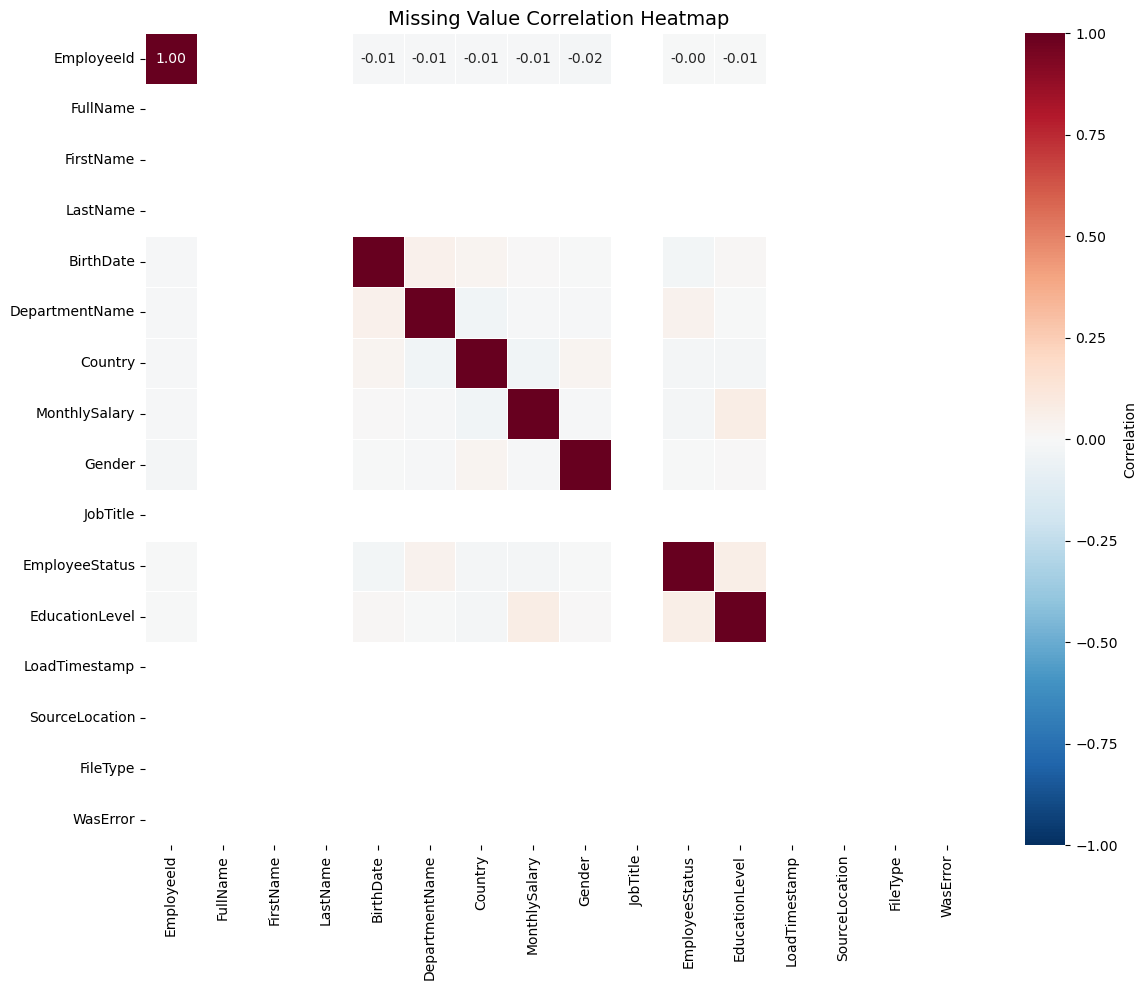

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate missing indicator matrix
missing_matrix = df.isna().astype(int)

# Compute correlation of missing indicators
missing_corr = missing_matrix.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(missing_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Missing Value Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [54]:
print("=== MISSING DATA MECHANISM ANALYSIS ===\n")

# Calculate missing indicator matrix
missing_matrix = df.isna().astype(int)

# 1. Correlation of missing values (MCAR check)
print("--- MCAR Check: Missing Value Correlations ---")
missing_corr = missing_matrix.corr()
# If all correlations are near 0, it's MCAR
max_corr = missing_corr.where(~np.eye(len(missing_corr.columns), dtype=bool)).max().max()
min_corr = missing_corr.where(~np.eye(len(missing_corr.columns), dtype=bool)).min().min()
print(f"Max correlation between missing indicators: {max_corr:.4f}")
print(f"Min correlation between missing indicators: {min_corr:.4f}")

if abs(max_corr) < 0.1 and abs(min_corr) < 0.1:
    print("✅ Likely MCAR — missingness is random and uncorrelated with other missing values")
else:
    print("⚠️ Possible MAR/MNAR — missingness shows correlations with other missing values")

# 2. Check if missing values relate to observed data (MAR check)
print("\n--- MAR Check: Missing vs Observed Data ---")
# Check if rows with missing Gender have different salary distribution
for col_with_null in ['Gender', 'DepartmentName', 'BirthDate']:
    null_mask = df[col_with_null].isna()
    for col_to_check in ['MonthlySalary', 'Country', 'JobTitle']:
        if col_to_check not in ['Gender', 'DepartmentName', 'BirthDate']:
            if df[col_to_check].dtype in ['float64', 'int64']:
                null_mean = pd.to_numeric(df.loc[null_mask, col_to_check], errors='coerce').mean()
                non_null_mean = pd.to_numeric(df.loc[~null_mask, col_to_check], errors='coerce').mean()
                if abs(null_mean - non_null_mean) / max(null_mean, non_null_mean) > 0.1:
                    print(f"  {col_with_null} missing → {col_to_check} differs: null_mean={null_mean:.1f}, non_null_mean={non_null_mean:.1f}")

# 3. Check if missing values relate to the missing column itself (MNAR check)
print("\n--- MNAR Check: Missing Related to Column Value ---")
# MNAR is hard to detect without external data, but check if missingness correlates with time
print("If missingness varies over time, it may indicate MNAR (systematic cause):")
missing_by_time = df.groupby(pd.to_datetime(df['LoadTimestamp']).dt.date).apply(
    lambda x: x.isna().sum().sum()
)
if missing_by_time.nunique() > 1:
    print(f"  ⚠️ Missingness varies by load date — possible MNAR due to source system issues")
    print(missing_by_time)
else:
    print("  Missingness consistent over time")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 60, Finished, Available, Finished, False)

=== MISSING DATA MECHANISM ANALYSIS ===

--- MCAR Check: Missing Value Correlations ---
Max correlation between missing indicators: 0.0716
Min correlation between missing indicators: -0.0363
✅ Likely MCAR — missingness is random and uncorrelated with other missing values

--- MAR Check: Missing vs Observed Data ---

--- MNAR Check: Missing Related to Column Value ---
If missingness varies over time, it may indicate MNAR (systematic cause):
  ⚠️ Missingness varies by load date — possible MNAR due to source system issues
LoadTimestamp
2026-07-17    415
2026-07-18      4
dtype: int64


### 5.3.4) COMPLETENESS CHECKS: Missing Value Correlation: Determine if missingness in one column is related to another column


In [55]:
print("=== MISSING VALUE CORRELATION ANALYSIS ===\n")

# Calculate missing indicator matrix (1 if missing, 0 if present)
missing_matrix = df.isna().astype(int)

# Filter to only columns that have missing values
cols_with_missing = [col for col in df.columns if df[col].isna().sum() > 0]
missing_subset = missing_matrix[cols_with_missing]

print(f"Columns with missing values: {len(cols_with_missing)}")
print(f"Columns: {cols_with_missing}\n")

if len(cols_with_missing) > 1:
    # Calculate pairwise correlations
    print("--- Pairwise Missing Value Correlations ---")
    missing_corr = missing_subset.corr()
    
    # Find pairs with correlation > 0.1 (positive) or < -0.1 (negative)
    found_any = False
    for i in range(len(cols_with_missing)):
        for j in range(i+1, len(cols_with_missing)):
            col1, col2 = cols_with_missing[i], cols_with_missing[j]
            corr_val = missing_corr.loc[col1, col2]
            
            if abs(corr_val) > 0.1:
                direction = "together" if corr_val > 0 else "inversely"
                print(f"{col1} ↔ {col2}: r = {corr_val:.4f} (missing {direction})")
                found_any = True
    
    if not found_any:
        print("No significant correlations found — missing values are independent across columns")
else:
    print("Only one column has missing values — no correlation analysis possible")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 61, Finished, Available, Finished, False)

=== MISSING VALUE CORRELATION ANALYSIS ===

Columns with missing values: 8
Columns: ['EmployeeId', 'BirthDate', 'DepartmentName', 'Country', 'MonthlySalary', 'Gender', 'EmployeeStatus', 'EducationLevel']

--- Pairwise Missing Value Correlations ---
No significant correlations found — missing values are independent across columns


### 5.4.1) UNIQUENESS CHECKS: Duplicate Rows: Check if entire rows are duplicated

In [56]:
print("=== DUPLICATE ROW CHECK ===\n")

# Check for fully duplicated rows
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_count = df.duplicated().sum()

print(f"Total rows: {len(df)}")
print(f"Fully duplicated rows: {duplicate_count}")

if duplicate_count > 0:
    print(f"\n=== Duplicate Row Groups ({len(duplicate_rows)} rows affected) ===")
    # Group duplicates to show which rows are copies of which
    dup_groups = df[df.duplicated(keep=False)].groupby(list(df.columns)).apply(lambda x: list(x.index)).reset_index(name='RowIndices')
    for _, group in dup_groups.iterrows():
        print(f"Rows {group['RowIndices']} are identical duplicates")
else:
    print("No fully duplicated rows found - Clean")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 62, Finished, Available, Finished, False)

=== DUPLICATE ROW CHECK ===

Total rows: 1000
Fully duplicated rows: 0
No fully duplicated rows found - Clean


### 5.4.2) UNIQUENESS CHECKS: Duplicate IDs: Verify primary/unique key columns have no duplicates

In [57]:
print("=== DUPLICATE PRIMARY KEY CHECK ===\n")

# Check for duplicate EmployeeId (excluding nulls)
duplicate_ids = df[df['EmployeeId'].notna() & df.duplicated(subset=['EmployeeId'], keep=False)]
duplicate_id_count = df[df['EmployeeId'].notna()]['EmployeeId'].duplicated().sum()

print(f"Total non-null EmployeeId: {df['EmployeeId'].notna().sum()}")
print(f"Duplicate EmployeeId values: {duplicate_id_count}")

if duplicate_id_count > 0:
    print(f"\n=== Duplicate EmployeeId Details ===")
    dup_id_values = duplicate_ids['EmployeeId'].unique()
    for emp_id in dup_id_values:
        dup_rows = df[df['EmployeeId'] == emp_id]
        print(f"\nEmployeeId: {emp_id} - {len(dup_rows)} occurrences")
        print(dup_rows[['EmployeeId', 'FullName']].to_string(index=True))
else:
    print("All EmployeeId values are unique - Clean")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 63, Finished, Available, Finished, False)

=== DUPLICATE PRIMARY KEY CHECK ===

Total non-null EmployeeId: 998
Duplicate EmployeeId values: 3

=== Duplicate EmployeeId Details ===

EmployeeId: 100149 - 2 occurrences
   EmployeeId        FullName
23     100149      Emma Davis
24     100149  Karim Al-Farsi

EmployeeId: 100743 - 2 occurrences
    EmployeeId         FullName
366     100743  Abdullah Garcia
367     100743    Adel, Mostafa

EmployeeId: 100374 - 2 occurrences
    EmployeeId        FullName
743     100374     Aisha Moore
744     100374  Farah Al-Thani


## Issue #17: Duplicate EmployeeId Values
The `EmployeeId` column contains 3 duplicate pairs where the same ID is assigned to different employees.

**Examples:**
- `100149`: Emma Davis & Karim Al-Farsi
- `100743`: Abdullah Garcia & Adel, Mostafa
- `100374`: Aisha Moore & Farah Al-Thani

### Solution: Reassign Duplicates to the Next Available Sequential ID
Keep the first occurrence and reassign each duplicate to the next free ID in sequence, shifting existing rows if needed to maintain ordering.

In [58]:
# Get all EmployeeId values as sorted integers
all_ids = pd.to_numeric(df['EmployeeId'], errors='coerce').dropna().astype(int).sort_values().tolist()
taken_ids = set(all_ids)

# Find duplicate IDs
dup_ids = df[df['EmployeeId'].notna()]['EmployeeId'].value_counts()
dup_ids = dup_ids[dup_ids > 1].index.tolist()

for dup_id in dup_ids:
    dup_mask = df['EmployeeId'] == dup_id
    dup_indices = df[dup_mask].index.tolist()
    
    # Keep first occurrence, reassign the rest
    for idx in dup_indices[1:]:
        next_id = int(dup_id) + 1
        # Keep incrementing until we find a free ID
        while str(next_id) in taken_ids:
            next_id += 1
        df.loc[idx, 'EmployeeId'] = str(next_id)
        taken_ids.add(next_id)

# Verify
print("=== EmployeeId after fixing duplicates ===")
print(f"Duplicate EmployeeId count: {df[df['EmployeeId'].notna()]['EmployeeId'].duplicated().sum()}")
print(f"Total unique IDs: {df['EmployeeId'].nunique()}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 64, Finished, Available, Finished, False)

=== EmployeeId after fixing duplicates ===
Duplicate EmployeeId count: 0
Total unique IDs: 998


### 5.4.3) UNIQUENESS CHECKS: Duplicate IDs: Unique Value Counts: Check distinct value distribution in categorical columns (too few/too many)

In [59]:
print("=== UNIQUE VALUE DISTRIBUTION CHECK ===\n")

total_rows = len(df)
categorical_cols = ['Gender', 'DepartmentName', 'Country', 'EmployeeStatus', 'EducationLevel', 'JobTitle']

for col in categorical_cols:
    unique_count = df[col].nunique()
    unique_pct = (unique_count / total_rows) * 100
    non_null_rows = df[col].notna().sum()
    cardinality_ratio = unique_count / non_null_rows if non_null_rows > 0 else 0
    
    print(f"\n--- {col} ---")
    print(f"  Distinct values: {unique_count}")
    print(f"  Non-null rows: {non_null_rows}")
    print(f"  Cardinality ratio: {cardinality_ratio:.4f} ({unique_count}/{non_null_rows})")
    
    # Check for too few unique values (potential constant column)
    if unique_count == 1:
        print(f"  ⚠️ WARNING: Only 1 unique value — column may be constant")
    elif unique_count <= 2:
        print(f"  ℹ️ Binary column — {unique_count} unique values")
    
    # Check for too many unique values (potential free text or ID-like)
    if cardinality_ratio > 0.5:
        print(f"  ⚠️ WARNING: High cardinality ({cardinality_ratio:.1%}) — may be free text or unsuitable for categorical encoding")
    elif cardinality_ratio > 0.2:
        print(f"  ℹ️ Moderate-high cardinality ({cardinality_ratio:.1%})")
    
    # Show value distribution
    print(f"\n  Value counts:")
    print(df[col].value_counts(dropna=False).head(15).to_string())

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 65, Finished, Available, Finished, False)

=== UNIQUE VALUE DISTRIBUTION CHECK ===


--- Gender ---
  Distinct values: 2
  Non-null rows: 807
  Cardinality ratio: 0.0025 (2/807)
  ℹ️ Binary column — 2 unique values

  Value counts:
Gender
Female    414
Male      393
None      193

--- DepartmentName ---
  Distinct values: 12
  Non-null rows: 925
  Cardinality ratio: 0.0130 (12/925)

  Value counts:
DepartmentName
IT                 106
Sales               99
Environment         97
Operations          93
Human Resources     92
Finance             89
Safety              86
Marketing           85
None                75
Supply Chain        73
Production          64
Manufacturing       21
Logistics           20

--- Country ---
  Distinct values: 10
  Non-null rows: 964
  Cardinality ratio: 0.0104 (10/964)

  Value counts:
Country
India           117
Jordan          110
Qatar           108
UAE             104
Pakistan        103
Philippines      91
UK               88
Egypt            85
USA              85
Saudi Arabia     73
None 

### 5.5.1) CONSISTENCY CHECKS: Cross-Column Validation: Verify logical relationships (e.g., fname + lname = full_name)
- **Logical Contradictions**: Values that conflict logically (e.g., age < 18 and job_title = 'CEO')
- **Dependency Violations**: Business rule violations (e.g., employee_status = 'Terminated' but end_date is null)
- **Value Range Logic**: Ranges that don't make sense together (e.g., birth_date > hire_date)
- **Category Mapping**: Inconsistent codes/descriptions across related columns
- **Foreign Key Consistency**: Check that referenced values exist in lookup tables

In [60]:
print("=== CROSS-COLUMN VALIDATION ===\n")

# 1. Check if FirstName + LastName = FullName
print("--- FullName vs FirstName + LastName ---")
# Create expected FullName from FirstName and LastName
df['_expected_fullname'] = df['FirstName'].astype(str).str.strip() + ' ' + df['LastName'].astype(str).str.strip()
df['_actual_fullname'] = df['FullName'].astype(str).str.strip()

# Find mismatches
fullname_mismatch = df['_expected_fullname'].str.lower() != df['_actual_fullname'].str.lower()
print(f"Rows where FirstName + LastName ≠ FullName: {fullname_mismatch.sum()}")

if fullname_mismatch.sum() > 0:
    print("\nSample mismatches:")
    mismatch_sample = df.loc[fullname_mismatch, ['EmployeeId', 'FullName', 'FirstName', 'LastName']].head(10)
    for _, row in mismatch_sample.iterrows():
        print(f"  EmployeeId={row['EmployeeId']}: FullName='{row['FullName']}' vs '{row['FirstName']} {row['LastName']}'")

# 2. Check if FullName contains FirstName
print("\n--- FullName contains FirstName ---")
fname_in_fullname = df.apply(
    lambda row: str(row['FirstName']).strip().lower() in str(row['FullName']).strip().lower()
    if pd.notna(row['FirstName']) and pd.notna(row['FullName']) else True, axis=1
)
print(f"Rows where FullName does NOT contain FirstName: {(~fname_in_fullname).sum()}")

if (~fname_in_fullname).sum() > 0:
    print("\nSample mismatches:")
    for _, row in df[~fname_in_fullname][['EmployeeId', 'FullName', 'FirstName']].head(10).iterrows():
        print(f"  EmployeeId={row['EmployeeId']}: FullName='{row['FullName']}' vs FirstName='{row['FirstName']}'")

# 3. Check if FullName contains LastName
print("\n--- FullName contains LastName ---")
lname_in_fullname = df.apply(
    lambda row: str(row['LastName']).strip().lower() in str(row['FullName']).strip().lower()
    if pd.notna(row['LastName']) and pd.notna(row['FullName']) else True, axis=1
)
print(f"Rows where FullName does NOT contain LastName: {(~lname_in_fullname).sum()}")

if (~lname_in_fullname).sum() > 0:
    print("\nSample mismatches:")
    for _, row in df[~lname_in_fullname][['EmployeeId', 'FullName', 'LastName']].head(10).iterrows():
        print(f"  EmployeeId={row['EmployeeId']}: FullName='{row['FullName']}' vs LastName='{row['LastName']}'")

# Cleanup
df.drop(columns=['_expected_fullname', '_actual_fullname'], inplace=True)

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 67, Finished, Available, Finished, False)

=== CROSS-COLUMN VALIDATION ===

--- FullName vs FirstName + LastName ---
Rows where FirstName + LastName ≠ FullName: 70

Sample mismatches:
  EmployeeId=100129: FullName='Williams, Faisal' vs 'Faisal Williams'
  EmployeeId=100163: FullName='Ali, Mona' vs 'Mona Ali'
  EmployeeId=100164: FullName='Miller, Hassan' vs 'Hassan Miller'
  EmployeeId=100175: FullName='Al-Mansoori, David' vs 'David Al-Mansoori'
  EmployeeId=100197: FullName='Al-Mansoori, Fatima' vs 'Fatima Al-Mansoori'
  EmployeeId=100199: FullName='Johnson, Sara' vs 'Sara Johnson'
  EmployeeId=100228: FullName='Taylor, Abdullah' vs 'Abdullah Taylor'
  EmployeeId=100882: FullName='Al-Farsi, Hassan' vs 'Hassan Al-Farsi'
  EmployeeId=100900: FullName='Moore, David' vs 'David Moore'
  EmployeeId=100909: FullName='Mariam Martinez-Saeed' vs 'Mariam Martinez'

--- FullName contains FirstName ---
Rows where FullName does NOT contain FirstName: 0

--- FullName contains LastName ---
Rows where FullName does NOT contain LastName: 0


## Issue #18: FullName in "LastName, FirstName" Format
70 rows have `FullName` formatted as `LastName, FirstName` instead of `FirstName LastName`, causing a mismatch with the `FirstName` and `LastName` columns.

**Examples:**
- `Williams, Faisal` vs expected `Faisal Williams`
- `Ali, Mona` vs expected `Mona Ali`
- `Al-Mansoori, David` vs expected `David Al-Mansoori`

### Solution: Reformat "LastName, FirstName" to "FirstName LastName"

In [61]:
# Find rows where FullName contains a comma (LastName, FirstName format)
comma_mask = df['FullName'].astype(str).str.contains(',')

print(f"Rows with comma in FullName: {comma_mask.sum()}")

# Reformat "LastName, FirstName" → "FirstName LastName"
df.loc[comma_mask, 'FullName'] = df.loc[comma_mask, 'FullName'].apply(
    lambda x: ' '.join(reversed([part.strip() for part in x.split(',')]))
)

# Verify
print("\n=== FullName after reformatting ===")
df['_expected_fullname'] = df['FirstName'].astype(str).str.strip() + ' ' + df['LastName'].astype(str).str.strip()
fullname_mismatch = df['_expected_fullname'].str.lower() != df['FullName'].astype(str).str.strip().str.lower()
print(f"Rows where FirstName + LastName ≠ FullName: {fullname_mismatch.sum()}")

if fullname_mismatch.sum() > 0:
    print("\nRemaining mismatches:")
    for _, row in df.loc[fullname_mismatch, ['EmployeeId', 'FullName', 'FirstName', 'LastName']].head(10).iterrows():
        print(f"  EmployeeId={row['EmployeeId']}: FullName='{row['FullName']}' vs '{row['FirstName']} {row['LastName']}'")

# Cleanup
df.drop(columns=['_expected_fullname'], inplace=True)

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 68, Finished, Available, Finished, False)

Rows with comma in FullName: 67

=== FullName after reformatting ===
Rows where FirstName + LastName ≠ FullName: 3

Remaining mismatches:
  EmployeeId=100909: FullName='Mariam Martinez-Saeed' vs 'Mariam Martinez'
  EmployeeId=100408: FullName='Tamer Moore-Nasser' vs 'Tamer Moore'
  EmployeeId=100088: FullName='Sara Moore-Al-Farsi' vs 'Sara Moore'


## Issue #19: FullName Contains Hyphenated LastName Not Matching LastName Column
3 rows have `FullName` with a hyphenated last name (`Martinez-Saeed`, `Moore-Nasser`, `Moore-Al-Farsi`) but the `LastName` column only contains the first part.

**Examples:**
- FullName: `Mariam Martinez-Saeed` vs LastName: `Martinez`
- FullName: `Tamer Moore-Nasser` vs LastName: `Moore`
- FullName: `Sara Moore-Al-Farsi` vs LastName: `Moore`

### Solution: Extract Full LastName from FullName (Everything After First Name)

In [63]:
# For hyphenated last names, extract the full last name from FullName
# (everything after the first space)
df['LastName'] = df.apply(
    lambda row: ' '.join(str(row['FullName']).strip().split(' ')[1:])
    if pd.notna(row['FullName']) and pd.notna(row['FirstName'])
    else row['LastName'], axis=1
)

# Verify
print("=== LastName after extracting from FullName ===")
df['_expected_fullname'] = df['FirstName'].astype(str).str.strip() + ' ' + df['LastName'].astype(str).str.strip()
fullname_mismatch = df['_expected_fullname'].str.lower() != df['FullName'].astype(str).str.strip().str.lower()
print(f"Rows where FirstName + LastName ≠ FullName: {fullname_mismatch.sum()}")

if fullname_mismatch.sum() > 0:
    print("\nRemaining mismatches:")
    for _, row in df.loc[fullname_mismatch, ['EmployeeId', 'FullName', 'FirstName', 'LastName']].head(10).iterrows():
        print(f"  EmployeeId={row['EmployeeId']}: FullName='{row['FullName']}' vs '{row['FirstName']} {row['LastName']}'")
else:
    print("All FullName values match FirstName + LastName ✅")

# Cleanup
df.drop(columns=['_expected_fullname'], inplace=True)

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 70, Finished, Available, Finished, False)

=== LastName after extracting from FullName ===
Rows where FirstName + LastName ≠ FullName: 0
All FullName values match FirstName + LastName ✅


### 5.5.2) CONSISTENCY CHECKS: Logical Contradictions: Values that conflict logically (e.g., age < 18 and job_title = 'CEO')

In [64]:
print("=== LOGICAL CONTRADICTION CHECKS ===\n")

from datetime import datetime
current_year = datetime.now().year

# Calculate age from BirthDate
df['_birth_year'] = pd.to_datetime(df['BirthDate'], errors='coerce').dt.year
df['_age'] = current_year - df['_birth_year']

found_any = False

# 1. Check: EmployeeStatus = 'Terminated' but BirthDate is recent (age < 18 at termination)
print("--- Terminated employees under 18 ---")
terminated_underage = df[(df['EmployeeStatus'] == 'Terminated') & (df['_age'] < 18)]
if len(terminated_underage) > 0:
    print(f"{len(terminated_underage)} rows: Terminated but under 18")
    print(terminated_underage[['EmployeeId', 'FullName', 'BirthDate', '_age', 'EmployeeStatus']].head(10).to_string())
    found_any = True
else:
    print("Clean")

# 2. Check: EmployeeStatus = 'On Leave' or 'Active' but age > 100 (impossible)
print("\n--- Employees over 100 years old ---")
overage = df[df['_age'] > 100]
if len(overage) > 0:
    print(f"{len(overage)} rows: Age > 100")
    print(overage[['EmployeeId', 'FullName', 'BirthDate', '_age', 'EmployeeStatus']].head(10).to_string())
    found_any = True
else:
    print("Clean")

# 3. Check: EmployeeStatus = 'New Hire' but age < 18 (child labor)
print("\n--- New Hire employees under 18 ---")
newhire_underage = df[(df['EmployeeStatus'] == 'New Hire') & (df['_age'] < 18)]
if len(newhire_underage) > 0:
    print(f"{len(newhire_underage)} rows: New Hire but under 18")
    print(newhire_underage[['EmployeeId', 'FullName', 'BirthDate', '_age', 'JobTitle']].head(10).to_string())
    found_any = True
else:
    print("Clean")

# 4. Check: JobTitle contains 'Senior' or 'Manager' but age < 20 (unlikely)
print("\n--- Manager/Senior roles under 20 ---")
manager_underage = df[(df['_age'] < 20) & (df['JobTitle'].astype(str).str.contains('Manager|Senior', case=False))]
if len(manager_underage) > 0:
    print(f"{len(manager_underage)} rows: Manager/Senior role but under 20")
    print(manager_underage[['EmployeeId', 'FullName', 'BirthDate', '_age', 'JobTitle']].head(10).to_string())
    found_any = True
else:
    print("Clean")

# 5. Check: EducationLevel = 'PhD' but age < 22 (impossible to have PhD that young)
print("\n--- PhD holders under 22 ---")
phd_underage = df[(df['EducationLevel'] == 'PhD') & (df['_age'] < 22)]
if len(phd_underage) > 0:
    print(f"{len(phd_underage)} rows: PhD but under 22")
    print(phd_underage[['EmployeeId', 'FullName', 'BirthDate', '_age', 'EducationLevel']].head(10).to_string())
    found_any = True
else:
    print("Clean")

# 6. Check: Gender inconsistencies with name (e.g., Gender=Male but FirstName is typically female)
print("\n--- Potential Gender-Name mismatches ---")
male_names = ['Mona', 'Fatima', 'Aisha', 'Layla', 'Sara', 'Mariam', 'Noor', 'Heba', 'Farah', 'Dina', 'Laila', 'Aya', 'Emma', 'Emily', 'Olivia', 'Sophia']
female_names = ['Mohammed', 'Ahmed', 'Ali', 'Omar', 'Hassan', 'Abdullah', 'Karim', 'Tamer', 'Faisal', 'Mahmoud', 'Youssef', 'Khalid', 'Hamad', 'David', 'James', 'John']

gender_name_mismatch = df[
    ((df['Gender'] == 'Male') & (df['FirstName'].isin(male_names))) |
    ((df['Gender'] == 'Female') & (df['FirstName'].isin(female_names)))
]
if len(gender_name_mismatch) > 0:
    print(f"{len(gender_name_mismatch)} rows: Potential gender-name mismatch")
    print(gender_name_mismatch[['EmployeeId', 'FullName', 'FirstName', 'Gender']].head(10).to_string())
    found_any = True
else:
    print("Clean")

if not found_any:
    print("\n✅ No logical contradictions found")

# Cleanup helper columns
df.drop(columns=['_birth_year', '_age'], inplace=True)

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 71, Finished, Available, Finished, False)

=== LOGICAL CONTRADICTION CHECKS ===

--- Terminated employees under 18 ---
Clean

--- Employees over 100 years old ---
Clean

--- New Hire employees under 18 ---
Clean

--- Manager/Senior roles under 20 ---
Clean

--- PhD holders under 22 ---
Clean

--- Potential Gender-Name mismatches ---
301 rows: Potential gender-name mismatch
   EmployeeId          FullName FirstName  Gender
0      100126       Laila Patel     Laila    Male
1      100127      Olivia Moore    Olivia    Male
2      100128      Aisha Miller     Aisha    Male
3      100129   Faisal Williams    Faisal  Female
5      100131    Olivia Mostafa    Olivia    Male
7      100133     Emma Williams      Emma    Male
12     100138       Aisha Kamal     Aisha    Male
13     100139  Mahmoud Al-Harbi   Mahmoud  Female
15     100141          Sara Ali      Sara    Male
16     100142         Ali Patel       Ali  Female


## Issue #19: Gender-Name Mismatches
301 rows have `Gender` values that conflict with the real-world gender typically associated with the `FirstName`. Since the data is too inconsistent to derive gender from existing patterns, a reference list of male and female names was used.

### Solution: Correct Gender Based on FirstName Using Real-World Name-Gender Mapping
Male names: Abdullah, Ahmed, Ali, David, Faisal, Hamad, Hassan, James, John, Karim, Khalid, Mahmoud, Michael, Mohamed, Mostafa, Omar, Robert, Saad, Tamer, Youssef

Female names: Aisha, Ava, Aya, Dina, Emily, Emma, Farah, Fatima, Heba, Laila, Layla, Maha, Mariam, Mona, Noora, Nour, Olivia, Reem, Sara, Sophia

In [67]:
# Extract all unique first names with their current gender assignment
name_gender_map = df.groupby('FirstName')['Gender'].apply(lambda x: x.unique().tolist()).reset_index()
name_gender_map['Count'] = df.groupby('FirstName')['Gender'].count().values

# Show all unique first names
print(f"Total unique first names: {len(name_gender_map)}")
print("\nAll first names and their current gender values:")
for _, row in name_gender_map.iterrows():
    print(f"  {row['FirstName']}: Gender={row['Gender']}, Count={row['Count']}")

# Show names that appear with BOTH genders (ambiguous)
ambiguous = name_gender_map[name_gender_map['Gender'].apply(lambda x: len(x) > 1)]
print(f"\n=== Ambiguous names (appear with multiple genders): {len(ambiguous)} ===")
print(ambiguous.to_string(index=False))

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 74, Finished, Available, Finished, False)

Total unique first names: 40

All first names and their current gender values:
  Abdullah: Gender=['Male'], Count=23
  Ahmed: Gender=['Male'], Count=28
  Aisha: Gender=['Female'], Count=24
  Ali: Gender=['Male'], Count=19
  Ava: Gender=['Female'], Count=21
  Aya: Gender=['Female'], Count=27
  David: Gender=['Male'], Count=31
  Dina: Gender=['Female'], Count=27
  Emily: Gender=['Female'], Count=23
  Emma: Gender=['Female'], Count=21
  Faisal: Gender=['Male'], Count=20
  Farah: Gender=['Female'], Count=21
  Fatima: Gender=['Female'], Count=27
  Hamad: Gender=['Male'], Count=32
  Hassan: Gender=['Male'], Count=32
  Heba: Gender=['Female'], Count=16
  James: Gender=['Male'], Count=44
  John: Gender=['Male'], Count=21
  Karim: Gender=['Male'], Count=27
  Khalid: Gender=['Male'], Count=27
  Laila: Gender=['Female'], Count=27
  Layla: Gender=['Female'], Count=25
  Maha: Gender=['Female'], Count=25
  Mahmoud: Gender=['Male'], Count=23
  Mariam: Gender=['Female'], Count=22
  Michael: Gender=['M

In [66]:
# Real-world gender-name mapping
male_names = [
    'Abdullah', 'Ahmed', 'Ali', 'David', 'Faisal', 'Hamad', 'Hassan', 
    'James', 'John', 'Karim', 'Khalid', 'Mahmoud', 'Michael', 'Mohamed', 
    'Mostafa', 'Omar', 'Robert', 'Saad', 'Tamer', 'Youssef'
]

female_names = [
    'Aisha', 'Ava', 'Aya', 'Dina', 'Emily', 'Emma', 'Farah', 'Fatima', 
    'Heba', 'Laila', 'Layla', 'Maha', 'Mariam', 'Mona', 'Noora', 'Nour', 
    'Olivia', 'Reem', 'Sara', 'Sophia'
]

# Apply mapping: set Gender based on FirstName
df.loc[df['FirstName'].isin(male_names) & df['Gender'].isna(), 'Gender'] = 'Male'
df.loc[df['FirstName'].isin(female_names) & df['Gender'].isna(), 'Gender'] = 'Female'

# Fix mismatches: override Gender where FirstName clearly indicates a different gender
male_mismatch = df['FirstName'].isin(male_names) & (df['Gender'] == 'Female')
female_mismatch = df['FirstName'].isin(female_names) & (df['Gender'] == 'Male')

print(f"Male names with Female gender (corrected): {male_mismatch.sum()}")
print(f"Female names with Male gender (corrected): {female_mismatch.sum()}")

df.loc[male_mismatch, 'Gender'] = 'Male'
df.loc[female_mismatch, 'Gender'] = 'Female'

# Verify
print("\n=== Gender after name-based correction ===")
print(f"Value counts:\n{df['Gender'].value_counts(dropna=False)}")

# Check remaining mismatches
remaining = df[
    ((df['Gender'] == 'Male') & (df['FirstName'].isin(female_names))) |
    ((df['Gender'] == 'Female') & (df['FirstName'].isin(male_names)))
]
print(f"\nRemaining mismatches: {len(remaining)}")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 73, Finished, Available, Finished, False)

Male names with Female gender (corrected): 214
Female names with Male gender (corrected): 179

=== Gender after name-based correction ===
Value counts:
Gender
Male      532
Female    468
Name: count, dtype: int64

Remaining mismatches: 0


### 5.5.3) CONSISTENCY CHECKS: Dependency Violations: Business rule violations (e.g., employee_status = 'Terminated' but end_date is null)

In [68]:
print("=== DEPENDENCY VIOLATION CHECKS ===\n")

found_any = False

# 1. EmployeeStatus = 'Terminated' should have a past termination date (not in this dataset, but check what we can)
print("--- Terminated employees with missing BirthDate ---")
terminated_no_birth = df[(df['EmployeeStatus'] == 'Terminated') & (df['BirthDate'].isna())]
if len(terminated_no_birth) > 0:
    print(f"{len(terminated_no_birth)} rows: Terminated but no BirthDate")
    found_any = True
else:
    print("Clean")

# 2. EmployeeStatus = 'On Leave' but Missing BirthDate (should have complete records)
print("\n--- On Leave employees with missing BirthDate ---")
leave_no_birth = df[(df['EmployeeStatus'] == 'On Leave') & (df['BirthDate'].isna())]
if len(leave_no_birth) > 0:
    print(f"{len(leave_no_birth)} rows: On Leave but no BirthDate")
    found_any = True
else:
    print("Clean")

# 3. EmployeeStatus = 'New Hire' but Missing DepartmentName (new hires must have a department)
print("\n--- New Hire employees with missing DepartmentName ---")
newhire_no_dept = df[(df['EmployeeStatus'] == 'New Hire') & (df['DepartmentName'].isna())]
if len(newhire_no_dept) > 0:
    print(f"{len(newhire_no_dept)} rows: New Hire but no DepartmentName")
    print(newhire_no_dept[['EmployeeId', 'FullName', 'EmployeeStatus', 'DepartmentName']].head(10).to_string())
    found_any = True
else:
    print("Clean")

# 4. EducationLevel = 'PhD' but age would be < 25 (redundant with logical contradictions, but check dependency)
print("\n--- PhD holders with missing BirthDate ---")
phd_no_birth = df[(df['EducationLevel'] == 'PhD') & (df['BirthDate'].isna())]
if len(phd_no_birth) > 0:
    print(f"{len(phd_no_birth)} rows: PhD but no BirthDate")
    found_any = True
else:
    print("Clean")

# 5. Contractor with missing DepartmentName (contractors usually assigned to a department)
print("\n--- Contractor employees with missing DepartmentName ---")
contractor_no_dept = df[(df['EmployeeStatus'] == 'Contractor') & (df['DepartmentName'].isna())]
if len(contractor_no_dept) > 0:
    print(f"{len(contractor_no_dept)} rows: Contractor but no DepartmentName")
    print(contractor_no_dept[['EmployeeId', 'FullName', 'EmployeeStatus', 'DepartmentName']].head(10).to_string())
    found_any = True
else:
    print("Clean")

# 6. Active employees with missing critical fields (should have complete data)
print("\n--- Active employees with missing critical fields ---")
active_missing = df[(df['EmployeeStatus'] == 'Active') & 
                    (df[['DepartmentName', 'BirthDate', 'Gender', 'MonthlySalary']].isna().any(axis=1))]
if len(active_missing) > 0:
    print(f"{len(active_missing)} rows: Active but missing critical fields")
    for _, row in active_missing.head(10).iterrows():
        missing_fields = row[['DepartmentName', 'BirthDate', 'Gender', 'MonthlySalary']].index[row[['DepartmentName', 'BirthDate', 'Gender', 'MonthlySalary']].isna()].tolist()
        print(f"  EmployeeId={row['EmployeeId']}: Missing {missing_fields}")
    found_any = True
else:
    print("Clean")

if not found_any:
    print("\n✅ No dependency violations found")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 76, Finished, Available, Finished, False)

=== DEPENDENCY VIOLATION CHECKS ===

--- Terminated employees with missing BirthDate ---
9 rows: Terminated but no BirthDate

--- On Leave employees with missing BirthDate ---
9 rows: On Leave but no BirthDate

--- New Hire employees with missing DepartmentName ---
3 rows: New Hire but no DepartmentName
    EmployeeId           FullName EmployeeStatus DepartmentName
130     100881      Heba Al-Farsi       New Hire           None
299     100676  Noora Al-Mansoori       New Hire           None
806     100812       Mariam Saeed       New Hire           None

--- PhD holders with missing BirthDate ---
9 rows: PhD but no BirthDate

--- Contractor employees with missing DepartmentName ---
16 rows: Contractor but no DepartmentName
    EmployeeId             FullName EmployeeStatus DepartmentName
29      100155       Aisha Al-Thani     Contractor           None
37      100163             Mona Ali     Contractor           None
147     100899     Mona Al-Mansoori     Contractor           None
18

## Issues #20 - #25: Missing Critical Fields for Active Employees
Multiple dependency violations found where employee records are missing fields that should be required based on their status.

### Summary of Issues:

| Issue # | Status | Missing Field | Rows Affected |
|---|---|---|---|
| #20 | Terminated | BirthDate | 9 |
| #21 | On Leave | BirthDate | 9 |
| #22 | New Hire | DepartmentName | 3 |
| #23 | PhD Holders | BirthDate | 9 |
| #24 | Contractor | DepartmentName | 16 |
| #25 | Active | Various Critical Fields | 36 |

### Solution: Flag All Affected Rows for Stakeholder Review
These missing values cannot be reliably imputed without business context. Return to stakeholders for data source correction.

In [69]:
# Create summary of all dependency violations for stakeholder review
violations = [
    {'Issue': '#20', 'Status': 'Terminated', 'Missing_Field': 'BirthDate', 'Rows': 9},
    {'Issue': '#21', 'Status': 'On Leave', 'Missing_Field': 'BirthDate', 'Rows': 9},
    {'Issue': '#22', 'Status': 'New Hire', 'Missing_Field': 'DepartmentName', 'Rows': 3},
    {'Issue': '#23', 'Status': 'PhD Holders', 'Missing_Field': 'BirthDate', 'Rows': 9},
    {'Issue': '#24', 'Status': 'Contractor', 'Missing_Field': 'DepartmentName', 'Rows': 16},
    {'Issue': '#25', 'Status': 'Active', 'Missing_Field': 'Various (Dept, Birth, Gender, Salary)', 'Rows': 36}
]

violations_df = pd.DataFrame(violations)
print("=== DEPENDENCY VIOLATIONS - STAKEHOLDER REVIEW REQUIRED ===")
display(violations_df)

# Combine all affected rows for export
affected_mask = (
    ((df['EmployeeStatus'].isin(['Terminated', 'On Leave'])) & (df['BirthDate'].isna())) |
    ((df['EmployeeStatus'] == 'New Hire') & (df['DepartmentName'].isna())) |
    ((df['EducationLevel'] == 'PhD') & (df['BirthDate'].isna())) |
    ((df['EmployeeStatus'] == 'Contractor') & (df['DepartmentName'].isna())) |
    ((df['EmployeeStatus'] == 'Active') & (df[['DepartmentName', 'BirthDate', 'Gender', 'MonthlySalary']].isna().any(axis=1)))
)

affected_rows = df[affected_mask]
print(f"\nTotal unique affected rows: {len(affected_rows)} out of {len(df)} ({len(affected_rows)/len(df)*100:.1f}%)")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 78, Finished, Available, Finished, False)

=== DEPENDENCY VIOLATIONS - STAKEHOLDER REVIEW REQUIRED ===


SynapseWidget(Synapse.DataFrame, 64f47b3a-c67a-44e9-9971-3e587adbdf85)


Total unique affected rows: 75 out of 1000 (7.5%)


### 5.5.4) CONSISTENCY CHECKS: Value Range Logic: Ranges that don't make sense together (e.g., birth_date > hire_date)

In [70]:
print("=== VALUE RANGE LOGIC CHECKS ===\n")

from datetime import datetime
current_date = datetime.now()
current_year = current_date.year

found_any = False

# 1. BirthDate should be in the past (not future dates)
print("--- BirthDate in the future ---")
future_birth = pd.to_datetime(df['BirthDate'], errors='coerce') > current_date
if future_birth.sum() > 0:
    print(f"{future_birth.sum()} rows: BirthDate is in the future")
    print(df.loc[future_birth, ['EmployeeId', 'FullName', 'BirthDate']].head(10).to_string())
    found_any = True
else:
    print("Clean")

# 2. BirthDate should not be too old (e.g., before 1920)
print("\n--- BirthDate before 1926 (age > 100) ---")
too_old = pd.to_datetime(df['BirthDate'], errors='coerce').dt.year < 1926
if too_old.sum() > 0:
    print(f"{too_old.sum()} rows: BirthDate before 1926 (over 100 years old)")
    print(df.loc[too_old, ['EmployeeId', 'FullName', 'BirthDate']].head(10).to_string())
    found_any = True
else:
    print("Clean")

# 3. LoadTimestamp should not be in the future
print("\n--- LoadTimestamp in the future ---")
future_load = pd.to_datetime(df['LoadTimestamp'], errors='coerce') > current_date
if future_load.sum() > 0:
    print(f"{future_load.sum()} rows: LoadTimestamp is in the future")
    print(df.loc[future_load, ['EmployeeId', 'FullName', 'LoadTimestamp']].head(10).to_string())
    found_any = True
else:
    print("Clean")

# 4. LoadTimestamp should be after BirthDate (data loaded after person was born)
print("\n--- LoadTimestamp before BirthDate ---")
load_before_birth = pd.to_datetime(df['LoadTimestamp'], errors='coerce') < pd.to_datetime(df['BirthDate'], errors='coerce')
if load_before_birth.sum() > 0:
    print(f"{load_before_birth.sum()} rows: LoadTimestamp is before BirthDate")
    print(df.loc[load_before_birth, ['EmployeeId', 'FullName', 'BirthDate', 'LoadTimestamp']].head(10).to_string())
    found_any = True
else:
    print("Clean")

# 5. MonthlySalary range check: reasonable min/max ratio
print("\n--- MonthlySalary extreme range check ---")
salary_numeric = pd.to_numeric(df['MonthlySalary'], errors='coerce')
salary_extreme = (salary_numeric < 1000) | (salary_numeric > 100000)
if salary_extreme.sum() > 0:
    print(f"{salary_extreme.sum()} rows: MonthlySalary outside reasonable range (1000-100000)")
    print(df.loc[salary_extreme, ['EmployeeId', 'FullName', 'MonthlySalary']].head(10).to_string())
    found_any = True
else:
    print("Clean")

if not found_any:
    print("\n✅ No value range logic violations found")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 79, Finished, Available, Finished, False)

=== VALUE RANGE LOGIC CHECKS ===

--- BirthDate in the future ---
Clean

--- BirthDate before 1926 (age > 100) ---
Clean

--- LoadTimestamp in the future ---
Clean

--- LoadTimestamp before BirthDate ---
Clean

--- MonthlySalary extreme range check ---
Clean

✅ No value range logic violations found


### 5.5.5) CONSISTENCY CHECKS: Category Mapping: Inconsistent codes/descriptions across related columns (Data is random and this check would be pain to fix manually)

In [73]:
# print("=== CATEGORY MAPPING CONSISTENCY CHECKS ===\n")

# found_any = False

# # 1. Check if DepartmentName and JobTitle align logically
# print("--- DepartmentName vs JobTitle logical alignment ---")

# job_dept_expectations = {
#     'HR Specialist': 'Human Resources',
#     'Safety Officer': 'Safety',
#     'Environmental Engineer': 'Environment',
#     'Supply Chain Coordinator': 'Supply Chain',
#     'Marketing Analyst': 'Marketing',
#     'Accountant': 'Finance',
#     'IT Support': 'IT'
# }

# for job, expected_dept in job_dept_expectations.items():
#     mismatched = df[(df['JobTitle'] == job) & (df['DepartmentName'].notna()) & (df['DepartmentName'] != expected_dept)]
#     if len(mismatched) > 0:
#         print(f"\n  {job} expected in {expected_dept}: {len(mismatched)} mismatches")
#         print(f"  Actual departments: {mismatched['DepartmentName'].value_counts().to_dict()}")
#         found_any = True

# if not found_any:
#     print("  All job titles align with expected departments")

# # 2. Check if EducationLevel and JobTitle align
# print("\n--- EducationLevel vs JobTitle alignment ---")
# technical_jobs = ['Data Engineer', 'IT Support', 'Environmental Engineer']
# for job in technical_jobs:
#     edu_dist = df[df['JobTitle'] == job]['EducationLevel'].value_counts()
#     print(f"\n  {job} education distribution:")
#     print(f"  {edu_dist.to_dict()}")

# # 3. Check if Country and MonthlySalary have regional consistency
# print("\n--- Country vs MonthlySalary (summary stats) ---")
# df['_salary_num'] = pd.to_numeric(df['MonthlySalary'], errors='coerce')
# country_salary = df.groupby('Country')['_salary_num'].agg(['mean', 'min', 'max', 'count']).round(2)
# print(country_salary.to_string())
# df.drop(columns=['_salary_num'], inplace=True)

# # 4. Check if EmployeeStatus and DepartmentName have unusual patterns
# print("\n--- EmployeeStatus distribution by DepartmentName ---")
# status_dept = pd.crosstab(df['DepartmentName'], df['EmployeeStatus'])
# print(status_dept.to_string())

# if not found_any:
#     print("\n✅ No category mapping inconsistencies found")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 82, Finished, Available, Finished, False)

### 5.5.6) CONSISTENCY CHECKS: Foreign Key Consistency: Check that referenced values exist in lookup tables

### NOT POSSIBLE BECAUSE WE ARE WORKING WITH A SINGLE TABLE

### Rest of Data Quality checks are covered or not useful for this dataset

# 6) Data Type Conversion

In [75]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DateType, TimestampType, DecimalType
from pyspark.sql.functions import col, to_date, to_timestamp

# Convert pandas to Spark
spark_df = spark.createDataFrame(df)

# Apply correct data types
spark_df = spark_df.select(
    col('EmployeeId').cast(IntegerType()),
    col('FullName').cast(StringType()),
    col('FirstName').cast(StringType()),
    col('LastName').cast(StringType()),
    to_date(col('BirthDate'), 'yyyy-MM-dd').alias('BirthDate'),
    col('DepartmentName').cast(StringType()),
    col('Country').cast(StringType()),
    col('MonthlySalary').cast(DecimalType(10, 3)),
    col('Gender').cast(StringType()),
    col('JobTitle').cast(StringType()),
    col('EmployeeStatus').cast(StringType()),
    col('EducationLevel').cast(StringType()),
    to_timestamp(col('LoadTimestamp'), 'yyyy-MM-dd HH:mm:ss').alias('LoadTimestamp'),
    col('SourceLocation').cast(StringType()),
    col('FileType').cast(StringType()),
    col('WasError').cast(StringType())
)

# Verify schema
spark_df.printSchema()

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 84, Finished, Available, Finished, False)

root
 |-- EmployeeId: integer (nullable = true)
 |-- FullName: string (nullable = true)
 |-- FirstName: string (nullable = true)
 |-- LastName: string (nullable = true)
 |-- BirthDate: date (nullable = true)
 |-- DepartmentName: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- MonthlySalary: decimal(10,3) (nullable = true)
 |-- Gender: string (nullable = true)
 |-- JobTitle: string (nullable = true)
 |-- EmployeeStatus: string (nullable = true)
 |-- EducationLevel: string (nullable = true)
 |-- LoadTimestamp: timestamp (nullable = true)
 |-- SourceLocation: string (nullable = true)
 |-- FileType: string (nullable = true)
 |-- WasError: string (nullable = true)



# Univariate and Bivariate and Multivariate charts do later

# 10) Save Cleaned Data to STG Schema

Save the cleaned and standardized DataFrame to the STG schema as a table in the Fabric Lakehouse.

In [77]:
# Convert pandas DataFrame back to PySpark DataFrame
# spark_df = spark.createDataFrame(df) # Already have this variable when i changed the datatypes

# Write to STG schema as a managed table
spark_df.write.mode("overwrite").saveAsTable("STG.employee_txt_data_cleaned")

print(f"Saved {spark_df.count()} rows to STG.employee_txt_data_cleaned")

StatementMeta(, fefeb71d-9966-491f-9114-5d56cb9369c3, 86, Finished, Available, Finished, False)

Saved 1000 rows to STG.employee_txt_data_cleaned
